# A Machine Learning Model to Predict the Regional Economic Impact of Vision 2030 Mega-Projects in Saudi Arabia

## Research questions

**RQ1** — Can the features of Vision 2030 mega-projects be used to predict
the economic growth of the region?

**RQ2** — Which project attributes are most associated with regional
development outcomes?

**RQ3** — Is there an association between sector diversification in a
region's project portfolio and indicators of economic resilience?

**RQ4** — How are Vision 2030 projects distributed across Saudi Arabia's
regions, and is there evidence of geographic concentration?

---

| Question | Answered in |
|---|---|
| RQ4 | Step 3 — Regional Analysis |
| RQ1 | Step 7 — Model Comparison |
| RQ2 | Step 7 — Model Comparison (SHAP + Permutation) |
| RQ3 | Step 9 — Diversification and Resilience |

### Requirements

Input files, in the notebook's working directory:
`Saudi_projects_dataset.csv` · `gastat_unified_registered_employees.csv` · `gastat_real_estate.csv` · `gastat_population_province_sex_nationality.csv`

Network access is needed to install packages and to download the regional boundary file.

TabPFN requires an access token from https://ux.priorlabs.ai/ to download its pre-trained weights on first use, entered when prompted in Step 7. Inference runs locally.

## Step 1: Data Profiling

The source file is examined before any cleaning, to establish what is present, what is missing, and whether the file is internally consistent. Three checks are applied: missingness by column, duplication at row and project level, and agreement between each row's sector-level aggregate fields and the rows actually present for that sector. A fourth check tests whether recorded status agrees with recorded dates.

In [1]:
%pip install tabm tabpfn shap shapely folium -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.2/771.2 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 4.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import ast

In [3]:
import sys, pandas, numpy, sklearn, xgboost, torch, shap
print("python  ", sys.version.split()[0])
for m in (pandas, numpy, sklearn, xgboost, torch, shap):
    print(f"{m.__name__:8} {m.__version__}")

python   3.13.15
pandas   2.2.3
numpy    2.1.3
sklearn  1.6.1
xgboost  3.4.1
torch    2.11.0+cpu
shap     0.52.0


In [4]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*unauthenticated requests.*")
warnings.filterwarnings("ignore", category=RuntimeWarning, module="statsmodels")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}" if abs(v) < 1000 else f"{v:,.0f}")

In [5]:
raw = pd.read_csv("Saudi_projects_dataset.csv")
print("rows, cols:", raw.shape)
raw.head()

rows, cols: (2182, 11)


,sectors,sector_budgets,sector_num_projects,name_project,type_project,budget_project,startday_project,enddate_project,area_project,region_project,status_project
0,تجاري,1058790791316,902,برج غرفة الشرقية الاستثماري – Asharqia Chamber...,تجاري,"335,000,000",03-07-2019,31-12-2021,"7,752 متر مربع","المنطقة الشرقية, الدمام",تحت الإنشاء
1,تجاري,1058790791316,902,مقر برايس ووتر هاوس كوبرز – PWC Headquarter ...,"تجاري, سكني",NaN,01-01-2010,NaN,"8,000 متر مربع","منطقة الرياض, الرياض",تحت الإنشاء
2,تجاري,1058790791316,902,مقر المدفوعات السعودية – Saudi Payment Headqua...,"تجاري, سكني","1,178,000,000",01-01-2009,31-12-2014,"19,500 متر مربع","منطقة الرياض, الرياض",مكتمل
3,تجاري,1058790791316,902,الاحساء ستريب مول – Ahsa Strip Mall ...,تجاري,NaN,NaN,NaN,"19,888 متر مربع","المنطقة الشرقية, الأحساء",معلن عنه
4,تجاري,1058790791316,902,برج الدايل – Al-Dailh Tower,"فندقي, تجاري","120,000,000",01-06-2019,31-03-2022,"3,651 متر مربع","منطقة مكة المكرمة, جدة",تحت الإنشاء


In [6]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2182 entries, 0 to 2181
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sectors              2182 non-null   object 
 1   sector_budgets       2182 non-null   int64  
 2   sector_num_projects  2182 non-null   int64  
 3   name_project         2182 non-null   object 
 4   type_project         2182 non-null   object 
 5   budget_project       849 non-null    float64
 6   startday_project     1186 non-null   object 
 7   enddate_project      921 non-null    object 
 8   area_project         1695 non-null   object 
 9   region_project       2181 non-null   object 
 10  status_project       2182 non-null   object 
dtypes: float64(1), int64(2), object(8)
memory usage: 187.6+ KB


In [7]:
missing = raw.isna().sum().to_frame("n_missing")
missing["pct_missing"] = (missing["n_missing"] / len(raw) * 100).round(1)
missing.sort_values("pct_missing", ascending=False)

,n_missing,pct_missing
budget_project,1333,61.1000
enddate_project,1261,57.8000
startday_project,996,45.6000
area_project,487,22.3000
sector_num_projects,0,0.0000
sectors,0,0.0000
sector_budgets,0,0.0000
name_project,0,0.0000
type_project,0,0.0000
region_project,1,0.0000


In [8]:
print("exact duplicate rows:", raw.duplicated().sum())
print("duplicate project names:", raw.duplicated(subset=['name_project']).sum())

exact duplicate rows: 0
duplicate project names: 657


In [9]:
sector_en_map = {
    "تجاري": "Commercial", "ترفيهي/سياحي": "Leisure/Tourism",
    "تعليمي": "Education", "حكومي": "Government",
    "ديني/خيري": "Religious/Charity", "رياضي": "Sports",
    "سكني": "Residential", "صحي": "Health",
    "صناعي": "Industrial", "علمي": "Scientific",
}


def sector_reconciliation(raw):
    df = raw.copy()
    df['sector'] = df['sectors'].str.strip()

    check = df.groupby('sector').agg(
        rows_in_file=('name_project', 'count'),
        stated_num_projects=('sector_num_projects', 'first'),
        distinct_num_values=('sector_num_projects', 'nunique'),
        stated_budget=('sector_budgets', 'first'),
        budget_in_file=('budget_project', 'sum')
    )

    check['count_matches'] = check['rows_in_file'] == check['stated_num_projects']
    check['pct_budget_present'] = (check['budget_in_file'] / check['stated_budget'] * 100).round(1)
    check['budget_shortfall'] = check['stated_budget'] - check['budget_in_file']

    return check.rename(index=sector_en_map).sort_values('pct_budget_present')


check = sector_reconciliation(raw)
check

,rows_in_file,stated_num_projects,distinct_num_values,stated_budget,budget_in_file,count_matches,pct_budget_present,budget_shortfall
sector,,,,,,,,
Commercial,500,902,1,1058790791316,"108,619,738,773",False,10.3000,"950,171,052,543"
Residential,394,394,1,709916354518,"692,416,354,514",True,97.5000,"17,500,000,004"
Government,461,461,1,1436611825301,"1,409,054,412,858",True,98.1000,"27,557,412,443"
Sports,35,35,1,396629702256,"395,504,702,257",True,99.7000,"1,124,999,999"
Education,146,146,1,567443636867,"566,318,636,868",True,99.8000,"1,124,999,999"
Industrial,109,109,1,1091256760152,"1,089,421,760,152",True,99.8000,"1,835,000,000"
Leisure/Tourism,286,286,1,672120928423,"671,574,928,414",True,99.9000,"546,000,009"
Religious/Charity,62,62,1,473524096855,"473,524,096,855",True,100.0000,0.0000
Health,150,150,1,549859453510,"549,759,453,510",True,100.0000,"100,000,000"


The commercial sector is the only one where the file disagrees with itself: 500 rows are tagged commercial against a stated count of 902, and only 10.3% of the stated sector budget appears in the rows. Every other sector reconciles. These aggregate fields are not used as model features, so the discrepancy does not propagate into the analysis, but it is recorded here as a property of the source extraction.

In [10]:
def status_date_contradictions(raw):
    start = pd.to_datetime(raw["startday_project"], format="%d-%m-%Y", errors="coerce")
    end   = pd.to_datetime(raw["enddate_project"],  format="%d-%m-%Y", errors="coerce")
    status = raw["status_project"].astype(str).str.strip()
    data_cutoff = start.max()

    return {
        "completed, but no end date":                (status == "مكتمل") & end.isna(),
        "announced or proposed, but already ended":  status.isin(["معلن عنه", "المشاريع المقترحة"]) & (end < data_cutoff),
        "under construction, but ended before cutoff": (status == "تحت الإنشاء") & (end < data_cutoff),
        "delayed, planned end already passed":       (status == "متأخر") & (end < data_cutoff),
        "end date known, start date missing":        end.notna() & start.isna(),
    }

In [11]:
contradictions = status_date_contradictions(raw)

print("\nStatus against dates (row level):\n")
for label, mask in contradictions.items():
    print(f"  {int(mask.sum()):>5}  {label}")


Status against dates (row level):

     58  completed, but no end date
     37  announced or proposed, but already ended
     28  under construction, but ended before cutoff
    347  delayed, planned end already passed
    162  end date known, start date missing


## Step 2: Data Cleaning

The raw file is converted into two tables: a project-sector table retaining one row per tag, and a deduplicated project table. Four fields require reconstruction, area strings recorded in mixed Arabic units, dates of varying precision, regions expressed as city names, and sector tags carried in two inconsistent columns. Each transformation reports what it recovered and what it could not.

In [12]:
df = raw.copy()

In [13]:
df["name_truncated"] = (
    df["name_project"].str.strip().str.endswith("...") |
    df["name_project"].str.contains("\ufffd", regex=False)
    )
print("flagged as truncated/corrupted:", df["name_truncated"].sum(), "of", len(df))

flagged as truncated/corrupted: 362 of 2182


In [14]:
text_cols = df.select_dtypes(include=['object', 'string']).columns

for col in text_cols:
    nulls_before = raw[col].isna().sum()
    df[col] = df[col].astype('string').str.strip()
    if df[col].isna().sum() != nulls_before:
        print(f"Null count changed in {col}")

print("text columns normalised:", len(text_cols))
print("sector values now:", df["sectors"].dropna().unique()[:11].tolist())

text columns normalised: 8
sector values now: ['تجاري', 'ترفيهي/سياحي', 'تعليمي', 'حكومي', 'ديني/خيري', 'رياضي', 'سكني', 'علمي', 'صناعي', 'صحي']


In [15]:
print(f"Total projects: {len(df)}")
print(f"With a recorded area: {df['area_project'].notna().sum()}")
print(f"Distinct area strings: {df['area_project'].nunique()}\n")

print("Sample of raw area formats:")
for val in df["area_project"].dropna().unique()[:20]:
    print(" ", val)

Total projects: 2182
With a recorded area: 1695
Distinct area strings: 998

Sample of raw area formats:
  7,752 متر مربع
  8,000 متر مربع
  19,500 متر مربع
  19,888 متر مربع
  3,651 متر مربع
  4,100 متر مربع
  163,000 متر مربع
  7,940 متر مربع
  8,759 متر مربع
  7,000 متر مربع
  15,252 متر مربع
  17,344 متر مربع
  9,600 متر مربع
  5,400 متر مربع
  4744 متر مربع
  5,000 متر مربع
  278,709 متر مربع
  1,600 متر مربع
  20,000 متر مربع
  4,400 متر مربع


In [16]:
ar_digits = str.maketrans("٠١٢٣٤٥٦٧٨٩", "0123456789")
def _is_sqkm(s):
    return bool(re.search(r"(كلم|كم|كيلومتر|كيلو\s*متر)\s*(مربع\w*|²|2)", s))

In [17]:
def strip_area_symbol(s):
    return re.sub(r"([\u0600-\u06FF])\s*2(?!\d)", r"\1", s)

In [18]:
def is_linear_distance(s, is_sqkm):
    return bool(re.search(r"^\s*[\d.,]+\s*(كلم|كم\.?|كيلومتر|كيلو\s*متر|كيلو|متر)\s*$", s)) and not is_sqkm

In [19]:
def to_number(txt, is_sqkm):
    t = txt.replace(",", "").strip()
    if t.count(".") > 1:
        head, _, tail = t.rpartition(".")
        if len(tail) == 3:
            return float(t.replace(".", "")), "thousands"
        return float(head.replace(".", "") + "." + tail), "thousands"
    if re.fullmatch(r"\d{1,3}\.\d{3}", t):
        return (float(t), "decimal") if is_sqkm else (float(t.replace(".", "")), "thousands")
    if re.fullmatch(r"\d+\.\d{4,}", t):
        return float(t.replace(".", "")), "thousands"
    return float(t), "plain"

In [20]:
def try_multiplier(s, is_sqkm):
    match = re.search(r"([\d.,]+)\s*(ألف|الف|آلاف|الاف|مليون|ملايين)", s)
    if not match:
        return None
    num_str, word = match.groups()
    try:
        num = float(num_str.replace(",", ""))
    except ValueError:
        return [np.nan, "unparsed_multiplier"]
    mult = 1_000_000 if word in ("مليون", "ملايين") else 1_000
    return [num * mult * (1_000_000 if is_sqkm else 1), "ok"]

In [21]:
def try_hectare(s, is_sqkm):
    match = re.search(r"([\d.,]+)\s*هكتار", s)
    if not match:
        return None
    try:
        return [to_number(match.group(1), is_sqkm)[0] * 10_000, "ok"]
    except ValueError:
        return [np.nan, "unparsed_hectare"]

In [22]:
def try_acre(s, is_sqkm):
    match = re.search(r"([\d.,]+)\s*acres?", s, flags=re.I)
    if not match:
        return None
    try:
        return [to_number(match.group(1), is_sqkm)[0] * 4046.86, "ok"]
    except ValueError:
        return [np.nan, "unparsed_acre"]

In [23]:
def try_plain(s, is_sqkm):
    s_clean = re.sub(r"\([^)]*\)", "", s)
    s_clean = re.sub(r"[\u0600-\u06FFa-zA-Z²]+", " ", s_clean).strip()
    s_clean = re.sub(r"[^\d.,]", "", s_clean)
    if not re.search(r"\d", s_clean):
        return [np.nan, "unparsed_other"]
    try:
        val, _ = to_number(s_clean, is_sqkm)
    except ValueError:
        return [np.nan, "unparsed_other"]
    return [val * 1_000_000 if is_sqkm else val, "ok"]

In [24]:
def parse_area(raw_val):
    if pd.isna(raw_val):
        return pd.Series([np.nan, "empty"])

    s = str(raw_val).translate(ar_digits).replace("،", ",").strip()
    if s == "" or s.lower() == "nan":
        return pd.Series([np.nan, "empty"])

    is_sqkm = _is_sqkm(s)
    s = strip_area_symbol(s)
    s = s.replace("كليو", "كيلو")

    if not re.search(r"\d", s):
        return pd.Series([np.nan, "no_digits"])
    if re.search(r"\d\s*-\s*\d", s):
        return pd.Series([np.nan, "range"])
    if is_linear_distance(s, is_sqkm):
        return pd.Series([np.nan, "linear_distance_not_area"])

    for handler in (try_multiplier, try_hectare, try_acre):
        result = handler(s, is_sqkm)
        if result is not None:
            return pd.Series(result)

    return pd.Series(try_plain(s, is_sqkm))


df[["area_sqm", "area_parse_status"]] = df["area_project"].apply(parse_area)

had_value = int(df["area_project"].notna().sum())
parsed = int((df["area_parse_status"] == "ok").sum())
print(f"parsed: {parsed} of {had_value} non-null area strings ({parsed/had_value:.1%})")
print(df.loc[df["area_project"].notna(), "area_parse_status"].value_counts().to_string())

parsed: 1627 of 1695 non-null area strings (96.0%)
area_parse_status
ok                          1627
linear_distance_not_area      63
no_digits                      5


In [25]:
panel_end_year = 2025

df["start_date"] = pd.to_datetime(df["startday_project"], format="%d-%m-%Y", errors="coerce")
df["end_date"] = pd.to_datetime(df["enddate_project"], format="%d-%m-%Y", errors="coerce")

df["start_year"] = df["start_date"].dt.year
df["duration_days"] = (df["end_date"] - df["start_date"]).dt.days

end_before = (df["duration_days"] < 0).sum()
print("negative durations:", end_before)

negative durations: 0


In [26]:
print("start year range:", df["start_year"].min(), "->", df["start_year"].max())

start year range: 1971.0 -> 2020.0


In [27]:
def get_precision(dates, boundary):
    prec = pd.Series('exact', index=dates.index)
    prec[dates.isna()] = np.nan

    if boundary == 'start':
        prec[dates.dt.day == 1] = 'month-level'
        prec[(dates.dt.day == 1) & (dates.dt.month == 1)] = 'year-level'
    else:
        prec[dates.dt.is_month_end] = 'month-level'
        prec[(dates.dt.day == 31) & (dates.dt.month == 12)] = 'year-level'

    return prec


df['start_date_precision'] = get_precision(df['start_date'], 'start')
df['end_date_precision'] = get_precision(df['end_date'], 'end')

print(df['start_date_precision'].value_counts(dropna=False))
print(df['end_date_precision'].value_counts(dropna=False))

start_date_precision
NaN            996
exact          513
month-level    481
year-level     192
Name: count, dtype: int64
end_date_precision
NaN            1261
exact           527
year-level      217
month-level     177
Name: count, dtype: int64


In [28]:
future_end = df.loc[df['end_date'].dt.year > panel_end_year, 'end_date'].dt.year
print(f"end dates beyond {panel_end_year}:", future_end.count(), "->", sorted(int(y) for y in future_end.dropna().unique()))

end dates beyond 2025: 26 -> [2027, 2029, 2030, 2042]


Twenty-six projects carry an end date beyond the panel window, one as late as 2042. These are retained: the panel counts a project as completed only in the year its end date falls, so a date outside the window simply means the project never registers as completed within it. No end date was truncated or adjusted.

In [29]:
df[['start_date', 'end_date', 'duration_days', 'start_date_precision', 'end_date_precision']].head()

,start_date,end_date,duration_days,start_date_precision,end_date_precision
0,2019-07-03,2021-12-31,912.0000,exact,year-level
1,2010-01-01,NaT,NaN,year-level,NaN
2,2009-01-01,2014-12-31,"2,190",year-level,year-level
3,NaT,NaT,NaN,NaN,NaN
4,2019-06-01,2022-03-31,"1,034",month-level,month-level


In [30]:
no_region_word = df.loc[
    df["region_project"].notna()
    & ~df["region_project"].str.contains("منطقة"),
    "region_project"
].unique()

print("Values with no explicit 'منطقة' wording:", len(no_region_word))
print(*no_region_word, sep="\n")

Values with no explicit 'منطقة' wording: 9
القدية
ينبع, الأحساء, الجبيل الصناعية, الخرج, الطائف, عنيزة
الرياض
مكة المكرمة, الطائف
الأحساء
الجبيل, الجبيل الصناعية
حائل
مكة المكرمة, مدينة الملك عبدالله الاقتصادية, المدينة المنورة, جدة
جدة


In [31]:
location_to_region = {
    "القدية": "منطقة الرياض",
    "الرياض": "منطقة الرياض",
    "الخرج": "منطقة الرياض",
    "جدة": "منطقة مكة المكرمة",
    "مكة المكرمة": "منطقة مكة المكرمة",
    "الطائف": "منطقة مكة المكرمة",
    "مدينة الملك عبدالله الاقتصادية": "منطقة مكة المكرمة",
    "الجبيل": "المنطقة الشرقية",
    "الجبيل الصناعية": "المنطقة الشرقية",
    "الأحساء": "المنطقة الشرقية",
    "ينبع": "منطقة المدينة المنورة",
    "حائل": "منطقة حائل",
    "المدينة المنورة": "منطقة المدينة المنورة",
    "عنيزة": "منطقة القصيم",
}

In [32]:
region_to_en = {
    "منطقة الرياض": "Al-Riyadh", "منطقة مكة المكرمة": "Makkah Al-Mokarramah",
    "المنطقة الشرقية": "Eastern Region", "منطقة المدينة المنورة": "Al-Madinah Al-Monawarah",
    "منطقة القصيم": "Al-Qaseem", "منطقة جازان": "Jazan", "منطقة عسير": "Aseer",
    "منطقة حائل": "Hail", "منطقة تبوك": "Tabouk", "منطقة الباحة": "Al-Baha",
    "منطقة الجوف": "Al-Jouf", "منطقة الحدود الشمالية": "Northern Borders",
    "منطقة نجران": "Najran",
}

official_regions = list(region_to_en.values())

In [33]:
def split_tokens(value):
    return [t.strip() for t in str(value).split(",") if t.strip()]

In [34]:
def explicit_regions(tokens):
    explicit = [t for t in tokens if ("منطقة" in t or "المنطقة" in t)]
    return list(dict.fromkeys(explicit))

In [35]:
def inferred_regions(tokens):
    return [location_to_region[t] for t in tokens if t in location_to_region]

In [36]:
def split_region(value):
    if pd.isna(value) or str(value).strip().lower() == "nan":
        return pd.Series([np.nan, np.nan])

    tokens = split_tokens(value)

    explicit = explicit_regions(tokens)
    if explicit:
        cities = [t for t in tokens if t not in explicit]
        return pd.Series([", ".join(explicit),
                          ", ".join(cities) if cities else np.nan])

    inferred = inferred_regions(tokens)
    if inferred:
        return pd.Series([", ".join(dict.fromkeys(inferred)), ", ".join(tokens)])

    return pd.Series([np.nan, ", ".join(tokens)])

In [37]:
df[["region", "city"]] = df["region_project"].apply(split_region)
df["is_multi_region"] = df["region"].astype(str).str.contains(",", na=False)

df["region"] = df["region"].apply(
    lambda v: " / ".join(region_to_en.get(r.strip(), r.strip()) for r in str(v).split(","))
    if pd.notna(v) else pd.NA)

print("rows with no region:", int(df["region"].isna().sum()))
print("multi-region rows:", int(df["is_multi_region"].sum()))

rows with no region: 1
multi-region rows: 13


In [38]:
df[df["region"].isna()][["name_project","region_project", "city"]]

,name_project,region_project,city
207,فنادق تلال النسيم – AL NASSIM HOTEL,<NA>,NaN


In [39]:
df["n_types"] = df["type_project"].str.split(",").str.len()

print("projects by number of type tags:")
print(df["n_types"].value_counts().sort_index())

projects by number of type tags:
n_types
1     599
2     947
3     349
4     116
5      76
6      48
7      25
9      13
12      9
Name: count, dtype: int64


In [40]:
print("A project may carry several tags:\n")
print(df["type_project"].str.split(",").explode().str.strip().value_counts())

A project may carry several tags:

type_project
تجاري             1038
حكومي              798
سكني               698
ترفيهي/سياحي       549
فندقي              424
البنية التحتية     401
صحي                340
تعليمي             328
صناعي              152
ديني/خيري          144
علمي               102
رياضي               98
Name: count, dtype: int64


In [41]:
sector_en = {
    "تجاري": "Commercial", "حكومي": "Government", "سكني": "Residential",
    "ترفيهي/سياحي": "Leisure/Tourism", "صحي": "Health", "تعليمي": "Education",
    "صناعي": "Industrial", "ديني/خيري": "Religious/Charity",
    "علمي": "Scientific", "رياضي": "Sports",
    "فندقي": "Hospitality", "البنية التحتية": "Infrastructure",
}

status_en = {
    "تحت الإنشاء": "Under construction", "مكتمل": "Completed", "معلن عنه": "Announced",
    "متأخر": "Delayed", "المشاريع المقترحة": "Proposed", "متعثر": "Stalled", "ملغي": "Cancelled",
}

df["sector_en"] = df["sectors"].map(sector_en)
df["status_en"] = df["status_project"].map(status_en)

all_tag = {t.strip() for v in df["type_project"].dropna().astype(str) for t in v.split(",") if t.strip()}

print("All statuses mapped cleanly")
print(f"Sectors mapped: {len(all_tag)} distinct values found in type_project")

All statuses mapped cleanly
Sectors mapped: 12 distinct values found in type_project


In [42]:
print("-- Project Status Breakdown --")
print(df["status_en"].value_counts())

-- Project Status Breakdown --
status_en
Under construction    714
Completed             447
Announced             433
Delayed               347
Proposed              162
Stalled                63
Cancelled              16
Name: count, dtype: int64


In [43]:
print("-- Project Sector Breakdown --")
print(df["sector_en"].value_counts())

-- Project Sector Breakdown --
sector_en
Commercial           500
Government           461
Residential          394
Leisure/Tourism      286
Health               150
Education            146
Industrial           109
Religious/Charity     62
Scientific            39
Sports                35
Name: count, dtype: int64


In [44]:
at_risk_statuses = ["Delayed", "Stalled", "Cancelled"]
df["is_at_risk"] = df["status_en"].isin(at_risk_statuses)
df["is_at_risk"].value_counts(normalize=True).round(3)

,proportion
is_at_risk,
False,0.8050
True,0.1950


In [45]:
print("-- Budget Summary Statistics --")
print(df["budget_project"].describe().apply(lambda x: f"{x:,.2f}"))

print("\nZero/Negative budgets count:", (df["budget_project"] <= 0).sum())

-- Budget Summary Statistics --
count                849.00
mean       7,490,144,882.02
std       39,472,627,728.83
min              700,000.00
25%          110,000,000.00
50%          394,000,000.00
75%        1,600,000,000.00
max      375,000,000,000.00
Name: budget_project, dtype: object

Zero/Negative budgets count: 0


In [46]:
df["all_sectors"] = df["type_project"].apply(
    lambda v: sorted({sector_en[t.strip()] for t in str(v).split(",") if t.strip()})
)

projects_unique = (
    df.groupby(["name_project", "region"], as_index=False, dropna=False)
      .agg(budget_project=("budget_project", "first"),
           city=("city", "first"),
           is_multi_region=("is_multi_region", "first"),
           sectors_touched=("sector_en", lambda s: sorted(set(s))),
           all_sectors=("all_sectors", "first"),
           n_sectors=("sector_en", "nunique"),
           status_en=("status_en", "first"),
           area_sqm=("area_sqm", "first"))
)

print("original rows:", len(df), "-> unique projects:", len(projects_unique))
print("budget inflation from duplication:", f"{df['budget_project'].sum() - projects_unique['budget_project'].sum():,.0f}")

n_filed = projects_unique["sectors_touched"].apply(len).mean()
n_true  = projects_unique["all_sectors"].apply(len).mean()
print(f"mean sectors per project -- filing: {n_filed:.2f} | tags: {n_true:.2f}")

original rows: 2182 -> unique projects: 1529
budget inflation from duplication: 3,978,814,062,094
mean sectors per project -- filing: 1.43 | tags: 1.89


In [47]:
projects_unique.head()

,name_project,region,budget_project,city,is_multi_region,sectors_touched,all_sectors,n_sectors,status_en,area_sqm
0,Khouzama Hills – الخزامى هيلز,Al-Riyadh,NaN,الرياض,False,[Residential],[Residential],1,Under construction,"6,000"
1,Riyadh Metro Museum – متحف مترو الرياض,Al-Riyadh,NaN,الرياض,False,[Government],[Government],1,Under construction,NaN
2,The Valley – ذا ڤالي,Eastern Region,"31,500,000",الأحساء,False,[Commercial],[Commercial],1,Completed,"10,000"
3,آجا بلازا,Hail,NaN,حائل,False,[Commercial],[Commercial],1,Completed,"22,000"
4,أب تاون الرياض,Al-Riyadh,NaN,الرياض,False,[Residential],"[Commercial, Residential]",1,Proposed,"8,600,000"


In [48]:
dup_check = (
    df.groupby(["name_project", "region"], dropna=False)
    .agg(
        n_rows=("name_project", "size"),
        n_unique_budget=("budget_project", "nunique"),
        n_unique_area=("area_sqm", "nunique"),
    )
)

dup_only = dup_check[dup_check["n_rows"] > 1]
print(f"(project, region) more than one row: {len(dup_only)}")

(project, region) more than one row: 499


In [49]:
conflicting_budget = dup_only[dup_only["n_unique_budget"] > 1]
print(f"conflicting budget_project: {len(conflicting_budget)}")
if len(conflicting_budget) > 0:
    display(df[df.set_index(["name_project", "region"]).index.isin(conflicting_budget.index)]
            [["name_project", "region", "budget_project", "sectors"]].sort_values("name_project").head(5))

conflicting budget_project: 0


In [50]:
conflicting_area = dup_only[dup_only["n_unique_area"] > 1]
print(f"conflicting area_sqm: {len(conflicting_area)}")
if len(conflicting_area) > 0:
    display(df[df.set_index(["name_project", "region"]).index.isin(conflicting_area.index)]
            [["name_project", "region", "area_sqm", "sector_en"]]
            .sort_values("name_project").head(5))

conflicting area_sqm: 1


,name_project,region,area_sqm,sector_en
1692,أبراج الشاطئ – Beach Towers,Makkah Al-Mokarramah,"59,237",Residential
1716,أبراج الشاطئ – Beach Towers,Makkah Al-Mokarramah,"130,805",Residential


In [51]:
time_columns = ["start_year", "start_date", "end_date", "duration_days"]
time_by_project = (
    df.groupby(["name_project", "region"], dropna=False, as_index=False)
      .agg({col: "first" for col in time_columns})
)
projects_unique = projects_unique.merge(
    time_by_project,
    on=["name_project", "region"],
    how="left"
)
print(projects_unique.columns.tolist())

['name_project', 'region', 'budget_project', 'city', 'is_multi_region', 'sectors_touched', 'all_sectors', 'n_sectors', 'status_en', 'area_sqm', 'start_year', 'start_date', 'end_date', 'duration_days']


In [52]:
projects_unique["has_budget"] = projects_unique["budget_project"].notna()
df["has_budget"] = df["budget_project"].notna()

In [53]:
clean_cols = ["name_project", "name_truncated", "sector_en", "all_sectors", "n_types",
              "budget_project", "area_sqm", "region", "city", "is_multi_region",
              "area_parse_status", "has_budget",
              "start_date", "end_date", "duration_days", "start_year", "start_date_precision", "end_date_precision",
              "status_en", "is_at_risk"]
df[clean_cols].head()

,name_project,name_truncated,sector_en,all_sectors,n_types,budget_project,area_sqm,region,city,is_multi_region,area_parse_status,has_budget,start_date,end_date,duration_days,start_year,start_date_precision,end_date_precision,status_en,is_at_risk
0,برج غرفة الشرقية الاستثماري – Asharqia Chamber...,False,Commercial,[Commercial],1,"335,000,000","7,752",Eastern Region,الدمام,False,ok,True,2019-07-03,2021-12-31,912.0000,"2,019",exact,year-level,Under construction,False
1,مقر برايس ووتر هاوس كوبرز – PWC Headquarter,False,Commercial,"[Commercial, Residential]",2,NaN,"8,000",Al-Riyadh,الرياض,False,ok,False,2010-01-01,NaT,NaN,"2,010",year-level,NaN,Under construction,False
2,مقر المدفوعات السعودية – Saudi Payment Headqua...,False,Commercial,"[Commercial, Residential]",2,"1,178,000,000","19,500",Al-Riyadh,الرياض,False,ok,True,2009-01-01,2014-12-31,"2,190","2,009",year-level,year-level,Completed,False
3,الاحساء ستريب مول – Ahsa Strip Mall,False,Commercial,[Commercial],1,NaN,"19,888",Eastern Region,الأحساء,False,ok,False,NaT,NaT,NaN,NaN,NaN,NaN,Announced,False
4,برج الدايل – Al-Dailh Tower,False,Commercial,"[Commercial, Hospitality]",2,"120,000,000","3,651",Makkah Al-Mokarramah,جدة,False,ok,True,2019-06-01,2022-03-31,"1,034","2,019",month-level,month-level,Under construction,False


In [54]:
df[clean_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2182 entries, 0 to 2181
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name_project          2182 non-null   string        
 1   name_truncated        2182 non-null   bool          
 2   sector_en             2182 non-null   object        
 3   all_sectors           2182 non-null   object        
 4   n_types               2182 non-null   int64         
 5   budget_project        849 non-null    float64       
 6   area_sqm              1627 non-null   float64       
 7   region                2181 non-null   object        
 8   city                  2153 non-null   object        
 9   is_multi_region       2182 non-null   bool          
 10  area_parse_status     2182 non-null   object        
 11  has_budget            2182 non-null   bool          
 12  start_date            1186 non-null   datetime64[ns]
 13  end_date          

In [55]:
projects_unique["is_at_risk"] = projects_unique["status_en"].isin(at_risk_statuses)
projects_unique["is_at_risk"].value_counts(normalize=True).round(3)

,proportion
is_at_risk,
False,0.8200
True,0.1800


In [56]:
def parse_sectors(val):
    if isinstance(val, list):
        return val
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except (ValueError, SyntaxError):
            return [val]
    return []

In [57]:
d_sector = projects_unique.copy()
d_sector["sector_en"] = d_sector["sectors_touched"].apply(parse_sectors)
d_sector = d_sector.explode("sector_en").dropna(subset=["sector_en"]).reset_index(drop=True)
d_sector_single = d_sector[~d_sector["is_multi_region"]].copy()

print(f"project-sector links used: {len(d_sector)} (filing column)")
print("\nSectors present only in type_project, therefore outside these measures:")
print(sorted(set(sector_en.values()) - set(df["sector_en"].dropna().unique())))

project-sector links used: 2181 (filing column)

Sectors present only in type_project, therefore outside these measures:
['Hospitality', 'Infrastructure']


In [58]:
mnar_by_status = projects_unique.groupby("status_en", dropna=False)["has_budget"].mean().sort_values(ascending=False)
print("has_budget rate by status_en (%):")
print((mnar_by_status * 100).round(1))

has_budget rate by status_en (%):
status_en
Delayed              61.7000
Stalled              60.6000
Completed            51.9000
Under construction   32.7000
Cancelled            28.6000
Announced            16.8000
Proposed             14.5000
Name: has_budget, dtype: float64


In [59]:
mnar_by_sector = d_sector.groupby("sector_en")["has_budget"].mean().sort_values(ascending=False)
print("has_budget rate by sector_en (%):")
print((mnar_by_sector * 100).round(1))

has_budget rate by sector_en (%):
sector_en
Industrial          68.8000
Government          58.4000
Sports              54.3000
Education           52.1000
Health              52.0000
Religious/Charity   51.6000
Scientific          41.0000
Leisure/Tourism     32.9000
Residential         28.8000
Commercial          15.4000
Name: has_budget, dtype: float64


Commercial projects disclose a budget least often of any sector, which accounts for the reconciliation gap observed in Step 1: the stated commercial sector budget is largely absent from the rows because commercial developers report it least. Disclosure is therefore patterned by both delivery stage and sector, and any budget-weighted measure inherits that pattern.

In [60]:
missing_unique = projects_unique.isna().sum().to_frame("n_missing")
missing_unique["pct_missing"] = (missing_unique["n_missing"] / len(projects_unique) * 100).round(2)
missing_unique.sort_values("pct_missing", ascending=False)

,n_missing,pct_missing
duration_days,982,64.2200
budget_project,951,62.2000
end_date,872,57.0300
start_date,686,44.8700
start_year,686,44.8700
area_sqm,434,28.3800
city,22,1.4400
region,1,0.0700
n_sectors,0,0.0000
all_sectors,0,0.0000


In [61]:
missing = [c for c in clean_cols if c not in df.columns]
assert not missing, f"columns not found in df: {missing}"

out_cols = clean_cols + ["sectors", "status_project", "region_project"]
df_clean = df[out_cols]
df_clean.to_csv("S21_Saudi_projects_clean.csv", index=False, encoding="utf-8-sig")
print("saved S21_Saudi_projects_clean.csv  ->", df_clean.shape, "(one row per project-sector pair)")

projects_unique.to_csv("S22_Saudi_projects_unique.csv", index=False, encoding="utf-8-sig")
print("saved S22_Saudi_projects_unique.csv ->", projects_unique.shape, "(one row per project)")

saved S21_Saudi_projects_clean.csv  -> (2182, 23) (one row per project-sector pair)
saved S22_Saudi_projects_unique.csv -> (1529, 16) (one row per project)


### Step 2 — Outcome

2,182 rows resolve to 1,529 projects, removing SAR 3.98 trillion of budget double-counting. Area was recovered from 96% of the strings that held one. Region was resolved for all but one project, eleven of which span more than one region. Missingness at project level is higher than at row level for every field, because projects carrying several sector tags are also those most likely to be documented: budget is absent for 62% of projects, start date for 45%.

## Step 3: Regional Analysis

Projects are aggregated to the thirteen administrative regions to describe how investment is distributed. Four measures are computed: the Gini coefficient and Theil T index on both budget and project count, a sector concentration index per region, and location quotients identifying where a region's sector mix departs from the national one. Budget-based and count-based measures are reported side by side throughout, because budget is disclosed for only part of the register.

In [62]:
is_single = ~projects_unique["is_multi_region"] & projects_unique["region"].isin(official_regions)
pu_single = projects_unique[is_single].copy()

multi = projects_unique[projects_unique["is_multi_region"]]
budget_pct = multi["budget_project"].sum() / projects_unique["budget_project"].sum() * 100

print(f"Multi-region projects excluded: {len(multi)} ({budget_pct:.2f}% of known national budget)")
print(f"Single region projects: {len(pu_single)} of {len(projects_unique)}")
no_region = int(projects_unique["region"].isna().sum())
print(f"Projects with no region: {no_region}")

Multi-region projects excluded: 11 (4.16% of known national budget)
Single region projects: 1517 of 1529
Projects with no region: 1


In [63]:
region_summary = (
    pu_single.groupby("region")
    .agg(
        n_projects=("name_project", "count"),
        total_budget_sar=("budget_project", "sum"),
        known_budget_count=("budget_project", "count"),
        total_area_sqm=("area_sqm", "sum"),
        known_area_count=("area_sqm", "count"),
        at_risk_count=("status_en", lambda s: s.isin(at_risk_statuses).sum()),
    )
    .reindex(official_regions)
)

counts = ["n_projects", "known_budget_count", "known_area_count", "at_risk_count"]
region_summary[counts] = region_summary[counts].fillna(0).astype(int)

region_summary["pct_projects"] = region_summary["n_projects"] / region_summary["n_projects"].sum() * 100
region_summary["pct_budget"]   = region_summary["total_budget_sar"] / region_summary["total_budget_sar"].sum() * 100
region_summary["at_risk_rate"] = region_summary["at_risk_count"] / region_summary["n_projects"].replace(0, np.nan) * 100
region_summary["total_budget_sar_billion"] = region_summary["total_budget_sar"] / 1e9
region_summary["budget_coverage_pct"] = ( region_summary["known_budget_count"] / region_summary["n_projects"] * 100).round(1)

region_summary = (region_summary.round(2)
                  .sort_values("total_budget_sar", ascending=False)
                  .rename_axis("region").reset_index())

assert len(region_summary) == 13, f"expected 13 regions, found {len(region_summary)}"

cols_to_display = ["region", "n_projects", "pct_projects",
                   "total_budget_sar_billion", "pct_budget",
                   "known_budget_count", "at_risk_rate", "budget_coverage_pct"]

### RQ4 — Regional distribution and concentration

> **RQ4 — How are Vision 2030 projects distributed across Saudi
> Arabia's regions, and is there evidence of geographic concentration?**

In [64]:
region_summary_display = region_summary[cols_to_display].copy()
region_summary_display.to_csv("S31_region_summary.csv", index=False)
region_summary_display

,region,n_projects,pct_projects,total_budget_sar_billion,pct_budget,known_budget_count,at_risk_rate,budget_coverage_pct
0,Makkah Al-Mokarramah,474,31.2500,874.7200,38.3400,154,11.8100,32.5000
1,Eastern Region,220,14.5000,482.5500,21.1500,97,21.8200,44.1000
2,Al-Riyadh,488,32.1700,416.1400,18.2400,124,19.6700,25.4000
3,Al-Madinah Al-Monawarah,97,6.3900,212.6400,9.3200,60,22.6800,61.9000
4,Jazan,45,2.9700,191.3300,8.3900,33,15.5600,73.3000
5,Northern Borders,10,0.6600,59.6100,2.6100,6,50.0000,60.0000
6,Aseer,32,2.1100,13.3000,0.5800,17,18.7500,53.1000
7,Tabouk,31,2.0400,10.7300,0.4700,13,16.1300,41.9000
8,Al-Qaseem,47,3.1000,8.6200,0.3800,25,34.0400,53.2000
9,Hail,36,2.3700,4.7300,0.2100,26,19.4400,72.2000


These counts cover all single-region projects, whether or not a start date is recorded. The year-by-year panel built in Step 5 counts only dated projects, since an undated project cannot be placed in a specific year, the 686 undated projects enter that panel as a separate announced stock instead. Regional totals there are therefore lower than the totals shown here.

In [65]:
def gini_coefficient(values):
    x = np.sort(np.asarray(values, dtype=float))
    x = x[x >= 0]
    n = len(x)
    if n == 0 or x.sum() == 0:
        return np.nan
    cum = np.cumsum(x)
    return (2 * np.sum(np.arange(1, n + 1) * x) - (n + 1) * cum[-1]) / (n * cum[-1])

In [66]:
def theil_t_index(values):
    x = np.asarray(values, dtype=float)
    x = x[x > 0]
    n = len(x)
    if n == 0:
        return np.nan
    shares = x / x.sum()
    return float(np.sum(shares * np.log(shares * n)))

In [67]:
n_regions = len(region_summary)

gini_budget = gini_coefficient(region_summary["total_budget_sar"])
gini_projects = gini_coefficient(region_summary["n_projects"])
theil_budget = theil_t_index(region_summary["total_budget_sar"])
theil_projects = theil_t_index(region_summary["n_projects"])
theil_max = np.log(n_regions)

print(f"Regional inequality measures (n = {n_regions} regions)\n")
print(f"Gini  - budget concentration : {gini_budget:.3f}")
print(f"Gini  - project count        : {gini_projects:.3f}\n")

Regional inequality measures (n = 13 regions)

Gini  - budget concentration : 0.697
Gini  - project count        : 0.640



In [68]:
print(f"Theil T - budget              : {theil_budget:.3f} ({theil_budget / theil_max:.1%} of maximum)")
print(f"Theil T - project count      : {theil_projects:.3f} ({theil_projects / theil_max:.1%} of maximum)")
print(f"Theoretical maximum ln({n_regions}) = {theil_max:.3f} (everything in one region)")

Theil T - budget              : 0.924 (36.0% of maximum)
Theil T - project count      : 0.769 (30.0% of maximum)
Theoretical maximum ln(13) = 2.565 (everything in one region)


In [69]:
top_budget = region_summary.nlargest(3, "total_budget_sar")["total_budget_sar"].sum()
top_pct = (top_budget / region_summary["total_budget_sar"].sum()) * 100
print(f"\nShare of budget held by the top 3 regions: {top_pct:.1f}%")


Share of budget held by the top 3 regions: 77.7%


Projects tagged with three or more sectors are excluded from the concentration and specialisation measures. A project spanning that many sectors contributes to every one of them equally under a count-based index, which understates concentration in regions holding a few large mixed-use developments. The threshold is set at three rather than two because two-sector projects are the modal case in this register and excluding them would remove most of the data.

In [70]:
def hhi(shares):
    return np.sum(shares ** 2)

multi_sector_projects = projects_unique[projects_unique["n_sectors"] >= 3].set_index(["name_project", "region"]).index

sector_counts = (
    d_sector_single[
        ~d_sector_single.set_index(["name_project", "region"]).index.isin(multi_sector_projects)
    ]
    .groupby(["region", "sector_en"]).size()
)
sector_shares_by_region = sector_counts / sector_counts.groupby(level=0).sum()

region_hhi = sector_shares_by_region.groupby(level=0).apply(hhi).rename("sector_hhi")
region_hhi = region_hhi.sort_values(ascending=False)

In [71]:
region_hhi_display = region_hhi
region_hhi_display.to_csv("S32_region_sector_hhi_english.csv", encoding="utf-8-sig")
region_hhi_display

,sector_hhi
region,
Najran,0.2734
Al-Jouf,0.2595
Tabouk,0.2583
Al-Baha,0.2249
Northern Borders,0.2222
Al-Riyadh,0.2070
Hail,0.1980
Al-Qaseem,0.1922
Makkah Al-Mokarramah,0.1907


Concentration is highest in the smallest regions. Najran and Al Jouf hold twelve projects each and sit at the top; Madinah and Jazan hold more and sit at the bottom. A portfolio of a dozen projects cannot spread across ten sectors, so the index partly measures portfolio size. Step 9 tests whether any association with this index survives that confound.

In [72]:
region_summary_final = region_summary.set_index("region")
region_summary_final["sector_hhi"] = region_hhi
region_summary_final = region_summary_final.reset_index()

region_summary_final = region_summary_final.rename(columns={
    "n_projects":               "n_projects_all",
    "total_budget_sar":         "total_budget_sar_all",
    "total_budget_sar_billion": "total_budget_sar_billion_all",
    "known_budget_count":       "known_budget_count_all",
    "total_area_sqm":           "total_area_sqm_all",
    "known_area_count":         "known_area_count_all",
    "at_risk_count":            "at_risk_count_all",
    "at_risk_rate":             "at_risk_rate_all",
    "pct_projects":             "pct_projects_all",
    "pct_budget":               "pct_budget_all",
    "sector_hhi":               "sector_hhi_all",
})

region_summary_final.to_csv("S33_Saudi_regions_summary.csv", index=False, encoding="utf-8-sig")
print("saved S33_Saudi_regions_summary.csv ->", region_summary_final.shape)

saved S33_Saudi_regions_summary.csv -> (13, 13)


In [73]:
print(f"Budget range: {projects_unique['budget_project'].min():,.0f} to {projects_unique['budget_project'].max():,.0f} SAR")
print(f"Area range:   {projects_unique['area_sqm'].min():,.0f} to {projects_unique['area_sqm'].max():,.0f} sqm")

Budget range: 700,000 to 375,000,000,000 SAR
Area range:   500 to 440,000,000 sqm


In [74]:
projects_unique.nlargest(3, "budget_project")[["name_project", "budget_project", "region"]]

,name_project,budget_project,region
1149,مدينة الملك عبد الله الاقتصادية – KAEC,"375,000,000,000",Makkah Al-Mokarramah
1154,مدينة جازان للصناعات الاساسية والتحويلية – Jaz...,"100,000,000,000",Jazan
848,قطار الرياض – Riyadh Metro,"89,701,000,000",Al-Riyadh


In [75]:
projects_unique.nlargest(5, "area_sqm")[["name_project", "area_sqm", "region"]]

,name_project,area_sqm,region
1159,مدينة وعد الشمال – Waad Al Shamaal City,"440,000,000",Northern Borders
1156,مدينة سدير للصناعة والأعمال – Sudair City for ...,"258,000,000",Al-Riyadh
247,المجموعة الوطنية للاستزراع المائي – National A...,"250,000,000",Makkah Al-Mokarramah
1149,مدينة الملك عبد الله الاقتصادية – KAEC,"173,000,000",Makkah Al-Mokarramah
1516,وادي العسلاء مروج جدة – Murooj Jeddah,"130,000,000",Makkah Al-Mokarramah


In [76]:
ds_lq = d_sector_single[
    ~d_sector_single.set_index(["name_project", "region"]).index.isin(multi_sector_projects)
]

national_sector_share = ds_lq["sector_en"].value_counts(normalize=True)
region_sector_counts = ds_lq.groupby(["region", "sector_en"]).size()
region_totals = ds_lq.groupby("region").size()

location_quotient = (
    region_sector_counts.div(region_totals, level=0)
    .div(national_sector_share, level=1)
)

In [77]:
min_projects = 5
reliable_lq = location_quotient[region_sector_counts >= min_projects]

specialisations = reliable_lq[reliable_lq > 1.5].sort_values(ascending=False)

In [78]:
specialisations_display = pd.DataFrame({
    "LQ": specialisations.round(2),
    "n_projects": region_sector_counts[specialisations.index]
})

specialisations_display.to_csv("S34_location_quotients_english.csv", encoding="utf-8-sig")

print(f"Specialisations above 1.5, computed on region-sector pairs of at least {min_projects} projects:")
specialisations_display

Specialisations above 1.5, computed on region-sector pairs of at least 5 projects:


LQ  n_projects
region                  sector_en                           
Hail                    Education         3.6200           9
Al-Madinah Al-Monawarah Religious/Charity 3.4900           9
Hail                    Health            3.0900           8
Jazan                   Industrial        2.9800           9
Al-Madinah Al-Monawarah Education         2.4400          15
                        Industrial        2.4200          15
Aseer                   Health            2.0200           5
Jazan                   Education         2.0100           6
Tabouk                  Government        2.0000          19
Al-Jouf                 Government        1.9100           7
Najran                  Government        1.9100           7
Al-Riyadh               Scientific        1.8500          13
Al-Qaseem               Health            1.7700           6
Al-Baha                 Government        1.6400           6
Tabouk                  Leisure/Tourism   1.5800           9
Hail                    Government        1.5500          15
Al-Qaseem               Education         1.5300           5
Aseer                   Government        1.5100          14

Specialisation is concentrated in the smaller regions and is overwhelmingly governmental: six of the thirteen regions record a government quotient above 1.5, alongside education and health. None of the three investment hubs appears except Riyadh, in a single scientific category, because a large portfolio approaches the national sector mix by size alone.

In [79]:
total_known_budget = projects_unique["budget_project"].sum()
n_known = projects_unique["budget_project"].notna().sum()

top10 = projects_unique.nlargest(10, "budget_project")[["name_project", "budget_project", "region"]]
top10_share = top10["budget_project"].sum() / total_known_budget * 100

In [80]:
top10_display = top10.copy()

region_budget = region_summary.set_index("region")["total_budget_sar"]

top10_display["pct_national"] = (top10["budget_project"] / total_known_budget * 100).round(1)
top10_display["pct_region"] = (
    top10["budget_project"] / top10_display["region"].map(region_budget) * 100
).round(1)

top10_display.to_csv("S35_top10_projects_english.csv", index=False, encoding="utf-8-sig")

print(f"Top 10 projects represent {top10_share:.1f}% of the budget disclosed by "
      f"{n_known} of {len(projects_unique)} projects")
top10_display

Top 10 projects represent 42.2% of the budget disclosed by 578 of 1529 projects


,name_project,budget_project,region,pct_national,pct_region
1149,مدينة الملك عبد الله الاقتصادية – KAEC,"375,000,000,000",Makkah Al-Mokarramah,15.8000,42.9000
1154,مدينة جازان للصناعات الاساسية والتحويلية – Jaz...,"100,000,000,000",Jazan,4.2000,52.3000
848,قطار الرياض – Riyadh Metro,"89,701,000,000",Al-Riyadh,3.8000,21.6000
1324,مشروع الملك عبدالعزيز للنقل العام بمدينة الريا...,"84,000,000,000",Al-Riyadh,3.5000,20.2000
1058,مجمع صدارة للكيميائيات – Sadara Chemicals Complex,"75,000,000,000",Eastern Region,3.2000,15.5000
846,قطار الحرمين السريع – Haramain High Speed Rail,"63,000,000,000",Makkah Al-Mokarramah / Al-Madinah Al-Monawarah,2.6000,NaN
1327,"مشروع النقل العام بالدمام والقطيف – Dammam, Qa...","60,000,000,000",Eastern Region,2.5000,12.4000
847,قطار الخليج – Gulf Train – GCC,"57,750,000,000",Eastern Region,2.4000,12.0000
643,دار الهجرة – DAR AL HIJJRA,"55,000,000,000",Al-Madinah Al-Monawarah,2.3000,25.9000
1340,مصفاة ساتورب – SATORP,"45,000,000,000",Eastern Region,1.9000,9.3000


Every large region depends on one or two records. KAEC alone holds 42.9% of Makkah's disclosed budget, and the Jazan industrial city holds 52.3% of its region's. The budget-based inequality measures are therefore sensitive to individual projects in a way the count-based measures are not, which is why the count-based Gini is reported alongside as a lower bound.

### RQ4 — Answer

> **RQ4 — How are Vision 2030 projects distributed across Saudi Arabia's
> regions, and is there evidence of geographic concentration?**

**Yes — investment is heavily concentrated, more in budget than in
project count.**

- Gini: 0.697 for budget, 0.640 for project count
- Theil T: 0.924, or 36% of the maximum for thirteen regions
- Top three regions hold 77.7% of disclosed budget, the ten largest
  projects alone account for 42.2%
- Riyadh leads on project count but ranks third on budget
- Budget concentration rests on individual records: KAEC holds 42.9% of
  Makkah's disclosed budget and the Jazan industrial city 52.3% of its
  region's, which is why the count-based Gini is reported as a lower bound
- Location quotients show specialisation concentrated in the smaller
  regions and overwhelmingly governmental: six of thirteen regions record
  a government quotient above 1.5, while none of the three investment hubs
  appears except Riyadh in a single scientific category

## Step 4: Exploratory Data Analysis

The cleaned register is described before any modelling. Budget and area are examined on a logarithmic scale because both span several orders of magnitude, sector composition is compared against risk and status, and the distribution of start years is plotted — the last of these establishes the constraint that governs the modelling result in Step 7.

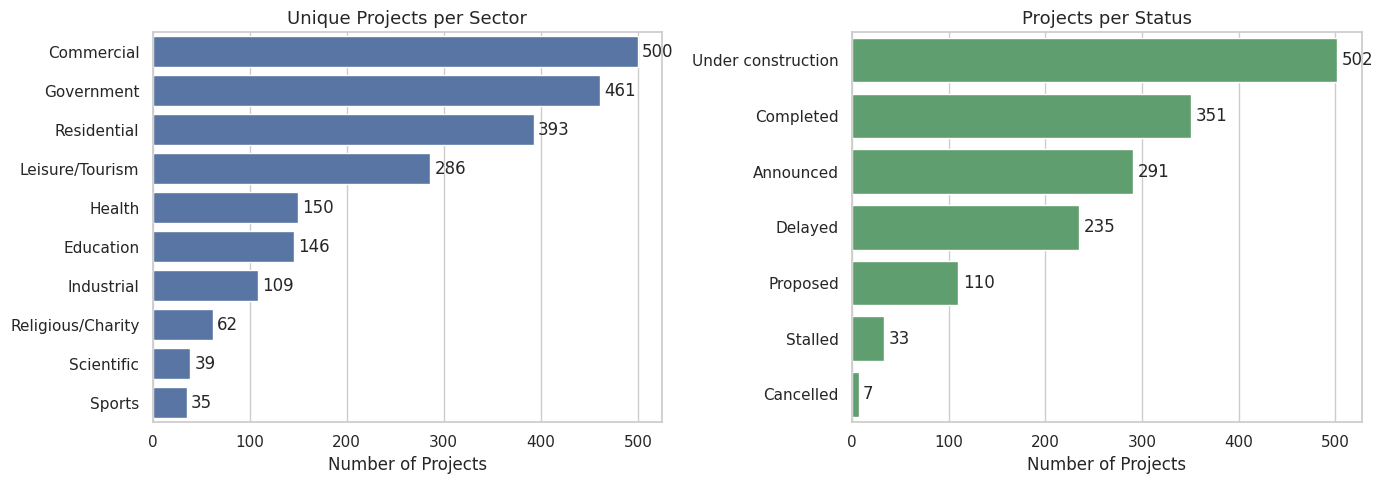

In [81]:
sec_order = projects_unique["sectors_touched"].explode().value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=sec_order.values, y=sec_order.index, ax=axes[0], color="#4C72B0")
axes[0].set_title("Unique Projects per Sector")
axes[0].set_xlabel("Number of Projects")
axes[0].set_ylabel("")
axes[0].bar_label(axes[0].containers[0], padding=3)

st_order = projects_unique["status_en"].value_counts()
sns.barplot(x=st_order.values, y=st_order.index, ax=axes[1], color="#55A868")
axes[1].set_title("Projects per Status")
axes[1].set_xlabel("Number of Projects")
axes[1].set_ylabel("")
axes[1].bar_label(axes[1].containers[0], padding=3)

plt.tight_layout()
plt.savefig("FS41_eda_projects_by_sector_status.png", dpi=150, bbox_inches="tight")
plt.show()

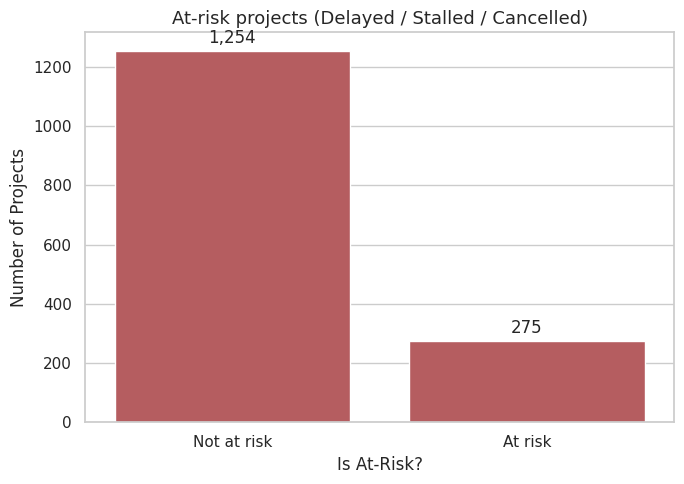

{False: 0.82, True: 0.18}


In [82]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(x="is_at_risk", data=projects_unique, color="#C44E52")
ax.set_title("At-risk projects (Delayed / Stalled / Cancelled)")
ax.set_xlabel("Is At-Risk?")
ax.set_ylabel("Number of Projects")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Not at risk", "At risk"])

for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha="center", va="bottom", xytext=(0, 3), textcoords="offset points")

plt.tight_layout()
plt.savefig("FS42_eda_at_risk_counts.png", dpi=150, bbox_inches="tight")
plt.show()
print(projects_unique["is_at_risk"].value_counts(normalize=True).round(3).to_dict())

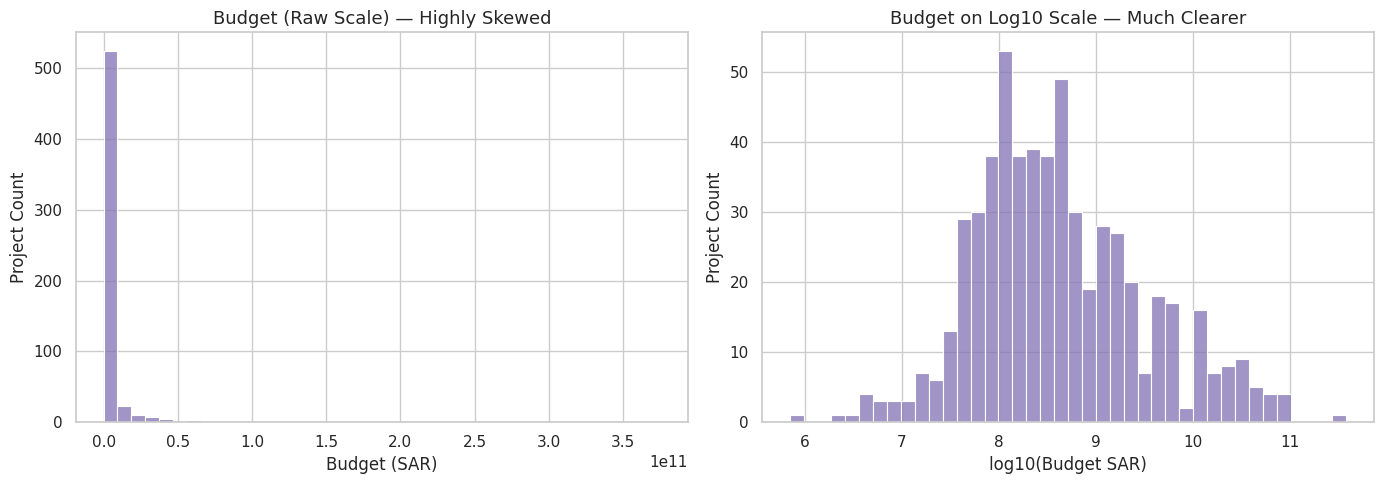

In [83]:
budget = projects_unique["budget_project"].dropna()
budget_positive = budget[budget > 0]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(budget, bins=40, ax=axes[0], color="#8172B3")
axes[0].set_title("Budget (Raw Scale) — Highly Skewed")
axes[0].set_xlabel("Budget (SAR)")
axes[0].set_ylabel("Project Count")
sns.histplot(np.log10(budget_positive), bins=40, ax=axes[1], color="#8172B3")
axes[1].set_title("Budget on Log10 Scale — Much Clearer")
axes[1].set_xlabel("log10(Budget SAR)")
axes[1].set_ylabel("Project Count")
plt.tight_layout()
plt.savefig("FS43_eda_budget_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [84]:
print(budget.describe().apply(lambda v: f"{v:,.0f}").to_string())

count                578
mean       4,118,198,863
std       18,783,057,916
min              700,000
25%          100,000,000
50%          302,710,000
75%        1,388,213,250
max      375,000,000,000


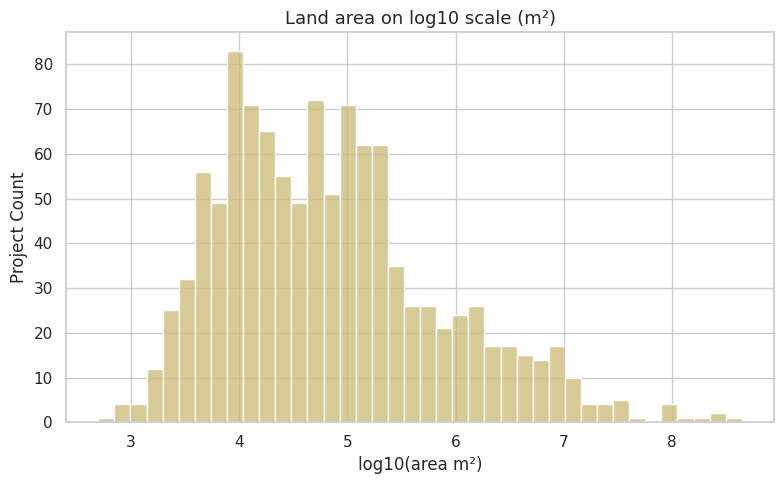

In [85]:
area = projects_unique["area_sqm"].dropna()
area_positive = area[area > 0]
plt.figure(figsize=(8, 5))
ax = sns.histplot(np.log10(area_positive), bins=40, color="#CCB974")
ax.set_title("Land area on log10 scale (m²)")
ax.set_xlabel("log10(area m²)")
ax.set_ylabel("Project Count")
plt.tight_layout()
plt.savefig("FS44_eda_area_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [86]:
print(area.describe().apply(lambda v: f"{v:,.0f}").to_string())

count          1,095
mean       2,482,090
std       19,564,584
min              500
25%           11,000
50%           52,000
75%          230,000
max      440,000,000


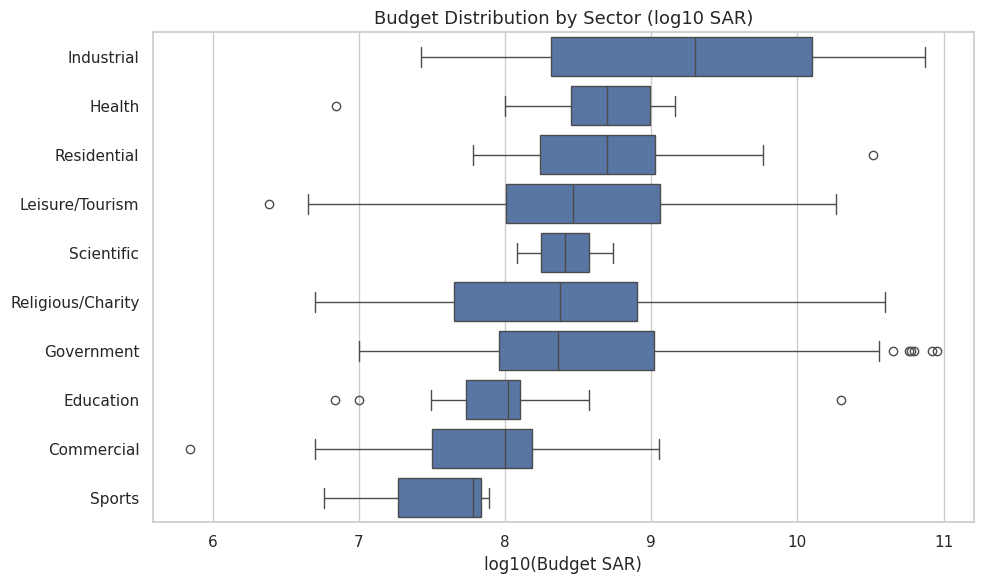

In [87]:
single_sector = projects_unique[projects_unique["n_sectors"] == 1].set_index(["name_project", "region"]).index

d = projects_unique[
    (projects_unique["budget_project"] > 0)
    & (projects_unique.set_index(["name_project", "region"]).index.isin(single_sector))
].copy()

d["sector_primary"] = d["sectors_touched"].str[0]
d["log_budget"] = np.log10(d["budget_project"])

order = d.groupby("sector_primary")["log_budget"].median().sort_values(ascending=False).index
plt.figure(figsize=(10, 6))
ax = sns.boxplot(data=d, x="log_budget", y="sector_primary", order=order, color="#4C72B0")
ax.set_title("Budget Distribution by Sector (log10 SAR)")
ax.set_xlabel("log10(Budget SAR)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("FS45_eda_budget_by_sector.png", dpi=150, bbox_inches="tight")
plt.show()

In [88]:
print(f"Chart based on {len(d)} single-sector projects with a known budget, "
      f"of {len(projects_unique)} projects overall")
print("Multi-sector projects are excluded because a single budget cannot be attributed to one sector")

Chart based on 372 single-sector projects with a known budget, of 1529 projects overall
Multi-sector projects are excluded because a single budget cannot be attributed to one sector


In [89]:
print("The education box plot shows one extreme outlier, these are the eight largest:")
d[d["sector_primary"] == "Education"].nlargest(8, "budget_project")[["name_project", "budget_project"]]

The education box plot shows one extreme outlier, these are the eight largest:


,name_project,budget_project
581,جامعة الأميرة نورة بنت عبدالرحمن,"20,000,000,000"
865,كلية البترجي للعلوم الطبية و التكنولوجيا – Bat...,"375,000,000"
913,مبنى الإدارة الرئيسية – جامعة حائل – Administr...,"269,000,000"
870,كلية الطب و العلوم الطبية التطبيقية – Medical ...,"190,213,912"
866,كلية البيان الأهلية,"180,000,000"
869,كلية الحاسب الألي-جامعة جازان,"139,000,000"
944,مبنى كلية علوم الحاسب الألي-جامعة طيبة,"124,000,000"
41,أكاديمية العالم,"120,000,000"


One education project is fifty times larger than the next. Sector-level budget summaries are therefore reported as medians on a log scale rather than means, and the sector boxes should be read as distributions rather than typical values.

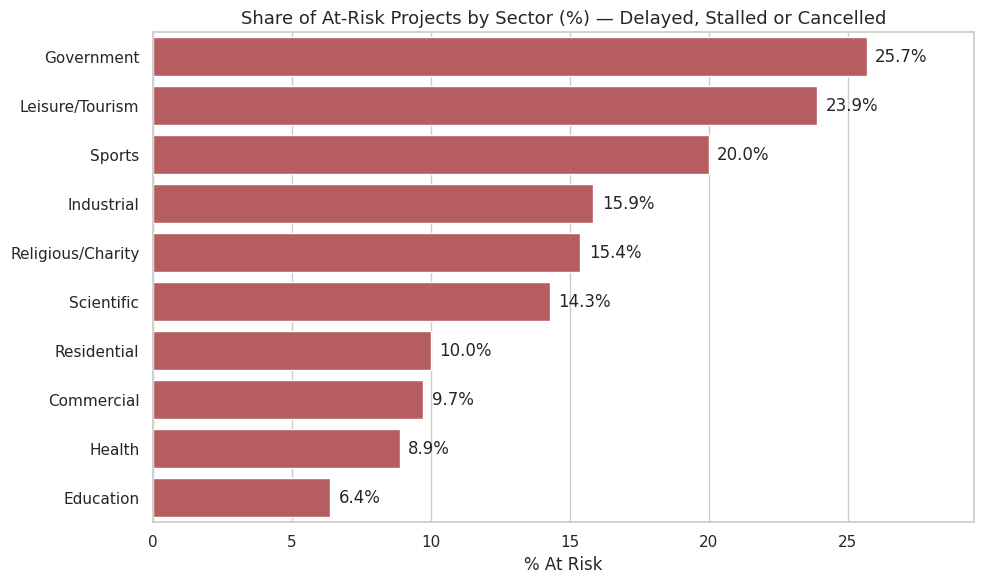

In [90]:
d_risk = projects_unique[projects_unique["n_sectors"] == 1].copy()
d_risk["sector_primary"] = d_risk["sectors_touched"].str[0]

risk_by_sector = (d_risk.groupby("sector_primary")["is_at_risk"].mean().sort_values(ascending=False) * 100)
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=risk_by_sector.values, y=risk_by_sector.index, color="#C44E52")
ax.set_title("Share of At-Risk Projects by Sector (%) — Delayed, Stalled or Cancelled")
ax.set_xlabel("% At Risk")
ax.set_ylabel("")
for i, v in enumerate(risk_by_sector.values):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center")
ax.set_xlim(0, max(risk_by_sector.values) * 1.15)
plt.tight_layout()
plt.savefig("FS46_eda_risk_by_sector.png", dpi=150, bbox_inches="tight")
plt.show()

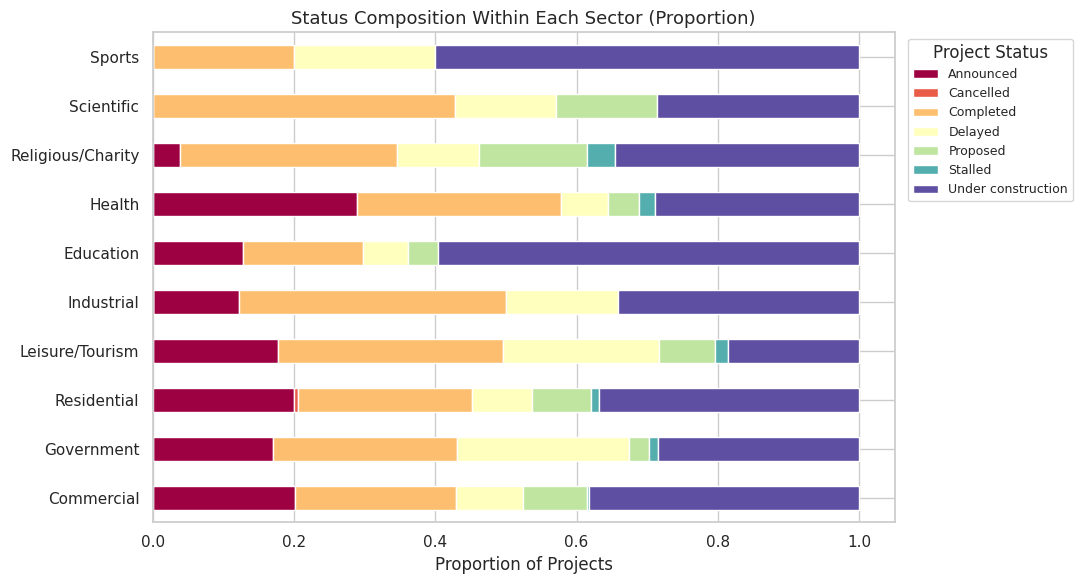

In [91]:
d_status = projects_unique[projects_unique["n_sectors"] == 1].copy()
d_status["sector_primary"] = d_status["sectors_touched"].str[0]
d_status = d_status.dropna(subset=["status_en"])

ct = pd.crosstab(d_status["sector_primary"], d_status["status_en"], normalize="index")
sector_order = d_status["sector_primary"].value_counts().index
ct = ct.loc[sector_order]
ax = ct.plot(kind="barh", stacked=True, figsize=(11, 6), colormap="Spectral")
plt.title("Status Composition Within Each Sector (Proportion)")
plt.xlabel("Proportion of Projects")
plt.ylabel("")
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", title="Project Status", fontsize=9)
plt.tight_layout()
plt.savefig("FS47_eda_status_by_sector.png", dpi=150, bbox_inches="tight")
plt.show()

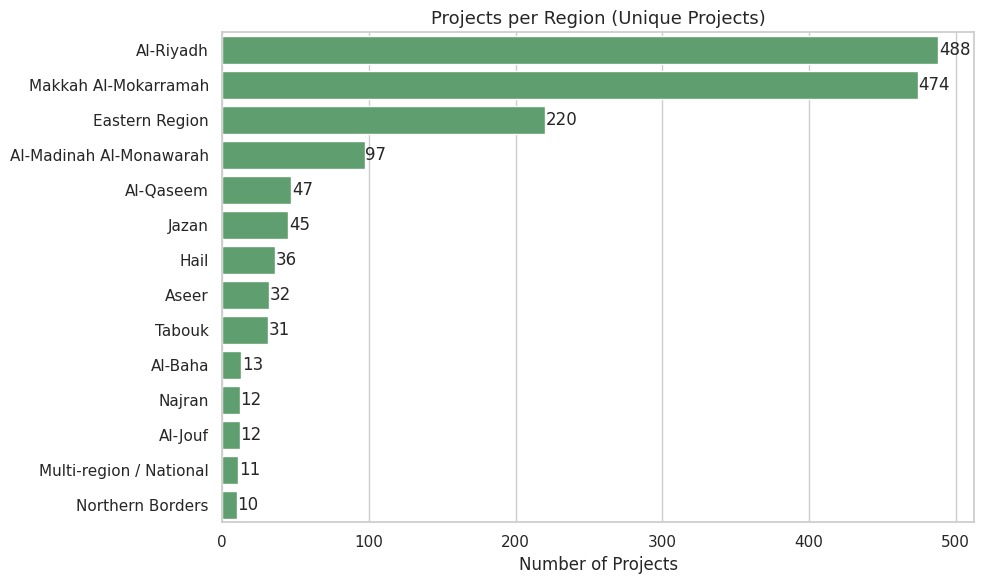

In [92]:
reg = projects_unique["region"]
reg = reg.mask(projects_unique["is_multi_region"], "Multi-region / National")
top = reg.value_counts()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=top.values, y=top.index, color="#55A868")
ax.set_title("Projects per Region (Unique Projects)")
ax.set_xlabel("Number of Projects")
ax.set_ylabel("")
for i, v in enumerate(top.values):
    ax.text(v + 0.5, i, f"{v:,}", va="center")

plt.tight_layout()
plt.savefig("FS48_eda_projects_by_region.png", dpi=150, bbox_inches="tight")
plt.show()

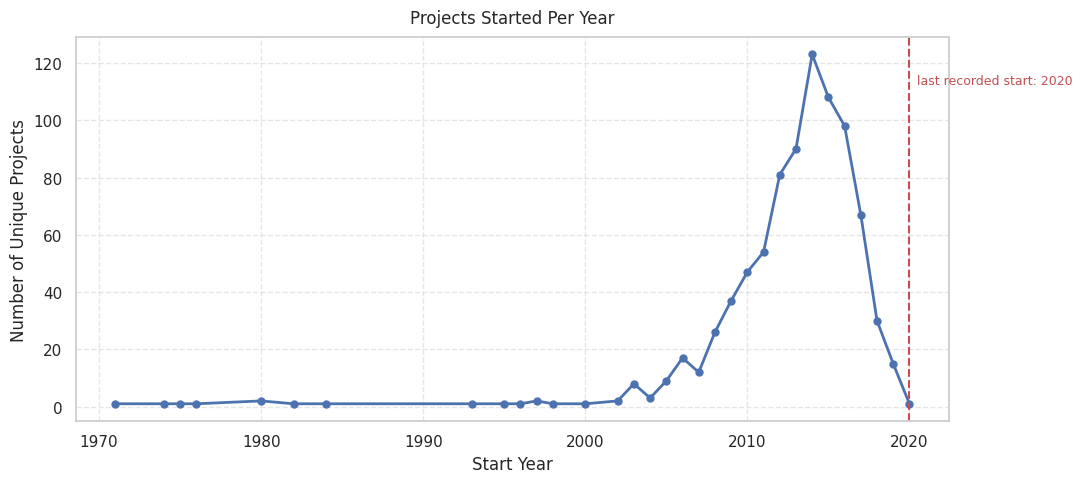

In [93]:
yr = projects_unique["start_year"].dropna().astype(int)
counts = yr.value_counts().sort_index()

plt.figure(figsize=(11, 5))
ax = counts.plot(marker="o", color="#4C72B0", linewidth=2, markersize=5)
ax.set_title("Projects Started Per Year", fontsize=12, pad=10)
ax.set_xlabel("Start Year")
ax.set_ylabel("Number of Unique Projects")
ax.axvline(yr.max(), color="#C44E52", linestyle="--", linewidth=1.5)
ax.text(yr.max(), ax.get_ylim()[1] * 0.9, f"  last recorded start: {yr.max()}",
        color="#C44E52", va="top", fontsize=9)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("FS49_project_starts_per_year.png", dpi=150, bbox_inches="tight")
plt.show()

The register records no project starting after 2020, while the outcome data extends to 2025. Every project-derived feature is therefore constant across the last five years of the panel. This is quantified in Step 7 and is the single most consequential property of the data.

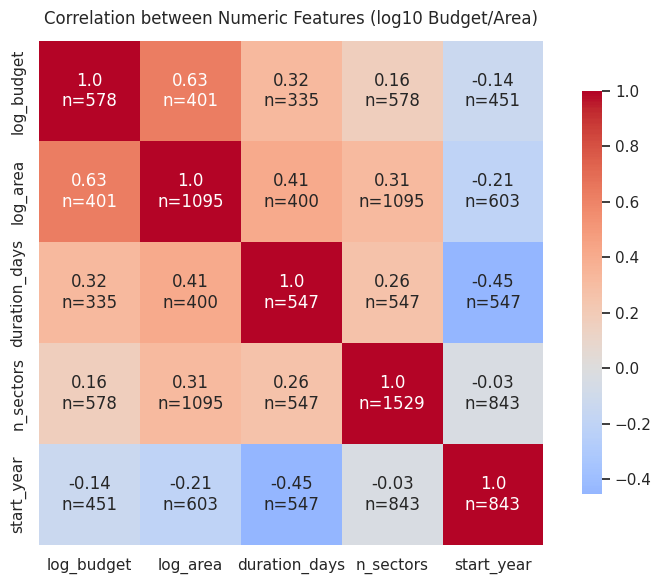

In [94]:
num = projects_unique.assign(
    log_budget=np.log10(projects_unique["budget_project"].where(projects_unique["budget_project"] > 0)),
    log_area=np.log10(projects_unique["area_sqm"].where(projects_unique["area_sqm"] > 0)),
)[["log_budget", "log_area", "duration_days", "n_sectors", "start_year"]]

corr = num.corr()

present = num.notna().astype(int)
n_pairs = present.T.dot(present)
labels = corr.round(2).astype(str) + "\nn=" + n_pairs.astype(str)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    corr,
    annot=labels,
    fmt="",
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8},
)

plt.title("Correlation between Numeric Features (log10 Budget/Area)", fontsize=12, pad=12)
plt.tight_layout()
plt.savefig("FS410_feature_correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

### Step 4 — Observations

Budget and area are both heavily right-skewed and are analysed on a log scale throughout. Sector risk varies by roughly a factor of two across sectors. Riyadh and Makkah dominate project counts, and the start-year distribution ends abruptly in 2020 — the constraint that Step 7 quantifies.

## Step 5: External Data Integration — Regional Employment Panel

Regional GDP is not published at province level, so registered employment serves as the outcome proxy, supported by a property price index and population estimates. Project attributes are aggregated to a region-year grid and merged with the three GASTAT sources. Before the panel is used, a diagnostic establishes how much of it actually varies over time.

In [95]:
emp_raw = pd.read_csv("gastat_unified_registered_employees.csv")

In [96]:
exclude_provinces = ["Unspecified", "Grand Total", "Outside Kingdom"]
emp_clean = emp_raw[~emp_raw["Province"].isin(exclude_provinces)]

productive = emp_clean[
    (emp_clean["Nationality"] == "Total") &
    (emp_clean["Sex"] == "Total") &
    (emp_clean["Registered Employee Category"].isin(["GOSI", "Civil Services"]))
]

employment_by_region_year = (
    productive.groupby(["Province", "Year Acc"], as_index=False)["Employees"].sum()
    .rename(columns={"Year Acc": "Year", "Employees": "registered_employment"})
)

In [97]:
employment_by_region_year["region"] = employment_by_region_year["Province"]

print(employment_by_region_year.shape)

(117, 4)


In [98]:
employment_by_region_year.drop(columns=["region"]).head(15)

,Province,Year,registered_employment
0,Al-Baha,2017,"80,272"
1,Al-Baha,2018,"70,165"
2,Al-Baha,2019,"64,847"
3,Al-Baha,2020,"67,332"
4,Al-Baha,2021,"64,144"
5,Al-Baha,2022,"67,004"
6,Al-Baha,2023,"69,113"
7,Al-Baha,2024,"70,653"
8,Al-Baha,2025,"69,156"
9,Al-Jouf,2017,"105,263"


In [99]:
def region_stock_summary(pu_y):
    rs = (
        pu_y.groupby("region")
        .agg(
            n_projects=("name_project", "count"),
            total_budget_sar=("budget_project", "sum"),
            known_budget_count=("budget_project", "count"),
            total_area_sqm=("area_sqm", "sum"),
            known_area_count=("area_sqm", "count"),
            at_risk_count=("status_en", lambda s: s.isin(at_risk_statuses).sum()),
        )
        .reindex(official_regions)
    )

    counts = ["n_projects", "known_budget_count", "known_area_count", "at_risk_count"]
    rs[counts] = rs[counts].fillna(0).astype(int)

    rs["pct_projects"]             = rs["n_projects"] / len(pu_y) * 100
    rs["pct_budget"]               = rs["total_budget_sar"] / pu_y["budget_project"].sum() * 100
    rs["at_risk_rate"]             = rs["at_risk_count"] / rs["n_projects"].replace(0, np.nan) * 100
    rs["total_budget_sar_billion"] = rs["total_budget_sar"] / 1e9

    return rs.round(2)

In [100]:
def add_flow_metrics(rs, dated, undated, cutoff_year, mode):
    started = dated[dated["start_year"] == cutoff_year]
    completed = dated[dated["end_year"] == cutoff_year]
    active = dated[
    (dated["start_year"] <= cutoff_year)
    & (dated["status_en"] != "Cancelled")
    & ((dated["end_year"] >= cutoff_year) | (dated["end_year"].isna()))
]

    flows = {
        "new_projects_this_year":   started.groupby("region")["name_project"].count(),
        "budget_started_this_year": started.groupby("region")["budget_project"].sum(),
        "active_projects":          active.groupby("region")["name_project"].count(),
        "active_budget":            active.groupby("region")["budget_project"].sum(),
        "completed_this_year":      completed.groupby("region")["name_project"].count(),
    }

    if mode == "recovered":
        flows["announced_projects"] = undated.groupby("region")["name_project"].count()
        flows["announced_budget"]   = undated.groupby("region")["budget_project"].sum()
    else:
        flows["announced_projects"] = 0.0
        flows["announced_budget"]   = 0.0

    for col, values in flows.items():
        rs[col] = values

    rs[list(flows)] = rs[list(flows)].fillna(0)
    return rs

In [101]:
def add_sector_hhi(rs, d_sector_single, cutoff_year, hhi_func):
    keys = d_sector_single.set_index(["name_project", "region"]).index
    ds_base = d_sector_single[
        d_sector_single["region"].isin(official_regions)
        & ~keys.isin(multi_sector_projects)
    ]

    ds_y = ds_base[ds_base["start_year"] <= cutoff_year]

    if len(ds_y) > 0:
        shares = ds_y.groupby(["region", "sector_en"]).size()
        shares = shares / shares.groupby(level=0).transform("sum")
        rs["sector_hhi"] = shares.groupby(level=0).apply(hhi_func)
    return rs

In [102]:
PANEL_MODE = "recovered"

if "end_year" not in projects_unique.columns:
    projects_unique["end_year"] = pd.to_datetime(
        projects_unique["end_date"], errors="coerce"
    ).dt.year

pu_valid = projects_unique[
    (~projects_unique["is_multi_region"])
    & (projects_unique["region"].isin(official_regions))
]
dated   = pu_valid[pu_valid["start_year"].notna()]
undated = pu_valid[pu_valid["start_year"].isna()]


def build_region_summary_for_year(cutoff_year, dated, undated, d_sector_single, hhi_func,
                                  mode="recovered"):
    pu_y = dated[dated["start_year"] <= cutoff_year].copy()

    rs = region_stock_summary(pu_y)
    rs = add_flow_metrics(rs, dated, undated, cutoff_year, mode)
    rs = add_sector_hhi(rs, d_sector_single, cutoff_year, hhi_func)

    rs = rs.reset_index()
    rs["Year"] = cutoff_year
    return rs

In [103]:
years_needed = sorted(employment_by_region_year["Year"].unique())

region_summary_by_year = pd.concat(
    [build_region_summary_for_year(y, dated, undated, d_sector_single, hhi, PANEL_MODE)
     for y in years_needed],
    ignore_index=True
)

n_dated   = projects_unique["start_year"].notna().sum()
n_undated = projects_unique["start_year"].isna().sum()
print(f"dated projects: {n_dated}  |  undated: {n_undated} ({n_undated/len(projects_unique):.1%})")
print("shape:", region_summary_by_year.shape)

dated projects: 843  |  undated: 686 (44.9%)
shape: (117, 20)


In [104]:
print("shape:", region_summary_by_year.shape)
region_summary_by_year.head(15)

shape: (117, 20)


,region,n_projects,total_budget_sar,known_budget_count,total_area_sqm,known_area_count,at_risk_count,pct_projects,pct_budget,at_risk_rate,total_budget_sar_billion,new_projects_this_year,budget_started_this_year,active_projects,active_budget,completed_this_year,announced_projects,announced_budget,sector_hhi,Year
0,Al-Riyadh,206,"318,073,224,067",88,"334,785,925",159,73,26.0400,16.9200,35.4400,318.0700,22.0000,"918,700,000",136,"273,577,582,690",37.0000,275,"98,009,889,768",0.1833,2017
1,Makkah Al-Mokarramah,246,"726,741,448,793",115,"790,339,360",175,40,31.1000,38.6500,16.2600,726.7400,25.0000,"3,462,000,000",156,"632,743,946,720",26.0000,212,"129,859,509,667",0.1697,2017
2,Eastern Region,131,"357,219,002,962",73,"62,272,897",96,46,16.5600,19.0000,35.1100,357.2200,13.0000,"22,969,875,006",96,"129,723,586,005",24.0000,76,"117,440,500,000",0.1734,2017
3,Al-Madinah Al-Monawarah,71,"211,398,546,992",54,"48,995,574",35,20,8.9800,11.2400,28.1700,211.4000,3.0000,"2,200,000,000",52,"116,038,822,288",8.0000,24,"1,244,135,218",0.1470,2017
4,Al-Qaseem,28,"7,845,733,434",20,"13,666,139",25,14,3.5400,0.4200,50.0000,7.8500,3.0000,"67,068,819",17,"5,356,877,434",5.0000,18,"771,700,000",0.2022,2017
5,Jazan,34,"174,430,992,731",28,"134,974,353",19,7,4.3000,9.2800,20.5900,174.4300,0.0000,0.0000,30,"171,491,492,731",7.0000,9,"148,478,157",0.1921,2017
6,Aseer,11,"7,514,654,594",7,"13,672,620",11,4,1.3900,0.4000,36.3600,7.5100,1.0000,"206,250,000",8,"7,006,250,000",1.0000,19,"5,784,066,158",0.2267,2017
7,Hail,28,"3,929,341,786",23,"3,188,304",16,7,3.5400,0.2100,25.0000,3.9300,0.0000,0.0000,19,"2,868,074,725",3.0000,8,"798,500,000",0.2301,2017
8,Tabouk,12,"7,615,555,229",8,"24,631,000",9,4,1.5200,0.4100,33.3300,7.6200,0.0000,0.0000,10,"7,465,567,322",3.0000,19,"3,112,285,366",0.2711,2017
9,Al-Baha,6,"2,325,971,645",5,"7,222,000",4,2,0.7600,0.1200,33.3300,2.3300,0.0000,0.0000,4,"2,065,227,953",0.0000,5,"218,000,000",0.3438,2017


### Do the project features actually vary across the panel window?

The panel is now built, but before it is modelled it must be established whether the project-derived features change from year to year. If the register stops before the outcome data does, later years carry identical feature vectors against differing outcomes, and no model can learn from that. The next four cells test this directly.

In [105]:
pu_years = projects_unique["start_year"]

print("-- time span of the project data --")
print("earliest start_year:", int(pu_years.min()))
print("latest start_year:  ", int(pu_years.max()))
print("panel extends to:   ", max(years_needed))

-- time span of the project data --
earliest start_year: 1971
latest start_year:   2020
panel extends to:    2025


In [106]:
print("-- new projects per year from 2010 --")
starts = pu_years.dropna().astype(int).value_counts().sort_index()
print(starts[starts.index >= 2010].to_string())

-- new projects per year from 2010 --
start_year
2010     47
2011     54
2012     81
2013     90
2014    123
2015    108
2016     98
2017     67
2018     30
2019     15
2020      1


In [107]:
feat_cols = [c for c in region_summary_by_year.columns
             if c not in ("region", "Year")
             and pd.api.types.is_numeric_dtype(region_summary_by_year[c])]

rsy_ok = region_summary_by_year[region_summary_by_year["region"].isin(official_regions)]

def within_std(sub):
    return sub.groupby("region")[feat_cols].std().mean()

freeze_report = pd.DataFrame({
    "full period 2017-2025": within_std(rsy_ok),
    "2017-2020": within_std(rsy_ok[rsy_ok["Year"] <= 2020]),
    "2021-2025": within_std(rsy_ok[rsy_ok["Year"] >= 2021]),
}).fillna(0)

scale = rsy_ok[feat_cols].abs().mean().replace(0, np.nan)
freeze_report["status 2021-2025"] = np.where(
    (freeze_report["2021-2025"] / scale).fillna(0) < 1e-6, "frozen", "moving")

freeze_report.to_csv("S51_feature_temporal_variation.csv", encoding="utf-8-sig")

In [108]:
frozen_late = freeze_report.index[freeze_report["status 2021-2025"] == "frozen"].tolist()
print(f"features frozen in 2021-2025: {len(frozen_late)} of {len(feat_cols)}\n")
print(freeze_report.to_string())

features frozen in 2021-2025: 15 of 18

                          full period 2017-2025      2017-2020     2021-2025 status 2021-2025
n_projects                               1.2252         1.6983        0.0000           frozen
total_budget_sar                  1,248,673,095  1,740,694,146        0.0000           frozen
known_budget_count                       0.3764         0.5353        0.0000           frozen
total_area_sqm                        1,032,483      1,394,586        0.0000           frozen
known_area_count                         1.0607         1.4882        0.0000           frozen
at_risk_count                            0.0256         0.0385        0.0000           frozen
pct_projects                             0.0812         0.1132        0.0000           frozen
pct_budget                               0.0547         0.0793        0.0000           frozen
at_risk_rate                             0.5792         0.8328        0.0000           frozen
total_budget_sar_bil

In [109]:
target_years = [int(y) for y in years_needed if y >= 2018]
dead_years = [y for y in target_years if int(starts.get(y, 0)) == 0]
print(f"target years with no new project: {len(dead_years)} of {len(target_years)} -> {dead_years}")

target years with no new project: 5 of 8 -> [2021, 2022, 2023, 2024, 2025]


Fifteen of eighteen project features hold no within-region variation across 2021–2025, and five of the eight target years contain no new project at all. Every model comparison that follows must be read against this: the panel has 104 rows, but only three years of them carry any project-side movement.

In [110]:
regional_panel = employment_by_region_year.merge(
    region_summary_by_year,
    on=["region", "Year"],
    how="left"
)
print(regional_panel.shape)
regional_panel.drop(columns=["region"]).head(15)

(117, 22)


,Province,Year,registered_employment,n_projects,total_budget_sar,known_budget_count,total_area_sqm,known_area_count,at_risk_count,pct_projects,pct_budget,at_risk_rate,total_budget_sar_billion,new_projects_this_year,budget_started_this_year,active_projects,active_budget,completed_this_year,announced_projects,announced_budget,sector_hhi
0,Al-Baha,2017,"80,272",6,"2,325,971,645",5,"7,222,000",4,2,0.7600,0.1200,33.3300,2.3300,0.0000,0.0000,4,"2,065,227,953",0.0000,5,"218,000,000",0.3438
1,Al-Baha,2018,"70,165",8,"2,370,971,645",6,"7,252,000",5,2,0.9700,0.1200,25.0000,2.3700,2.0000,"45,000,000",6,"2,110,227,953",0.0000,5,"218,000,000",0.2400
2,Al-Baha,2019,"64,847",8,"2,370,971,645",6,"7,252,000",5,2,0.9600,0.1200,25.0000,2.3700,0.0000,0.0000,6,"2,110,227,953",0.0000,5,"218,000,000",0.2400
3,Al-Baha,2020,"67,332",8,"2,370,971,645",6,"7,252,000",5,2,0.9600,0.1200,25.0000,2.3700,0.0000,0.0000,6,"2,110,227,953",0.0000,5,"218,000,000",0.2400
4,Al-Baha,2021,"64,144",8,"2,370,971,645",6,"7,252,000",5,2,0.9600,0.1200,25.0000,2.3700,0.0000,0.0000,6,"2,110,227,953",0.0000,5,"218,000,000",0.2400
5,Al-Baha,2022,"67,004",8,"2,370,971,645",6,"7,252,000",5,2,0.9600,0.1200,25.0000,2.3700,0.0000,0.0000,6,"2,110,227,953",0.0000,5,"218,000,000",0.2400
6,Al-Baha,2023,"69,113",8,"2,370,971,645",6,"7,252,000",5,2,0.9600,0.1200,25.0000,2.3700,0.0000,0.0000,6,"2,110,227,953",0.0000,5,"218,000,000",0.2400
7,Al-Baha,2024,"70,653",8,"2,370,971,645",6,"7,252,000",5,2,0.9600,0.1200,25.0000,2.3700,0.0000,0.0000,6,"2,110,227,953",0.0000,5,"218,000,000",0.2400
8,Al-Baha,2025,"69,156",8,"2,370,971,645",6,"7,252,000",5,2,0.9600,0.1200,25.0000,2.3700,0.0000,0.0000,6,"2,110,227,953",0.0000,5,"218,000,000",0.2400
9,Al-Jouf,2017,"105,263",6,"3,293,763,819",5,"9,425,740",6,1,0.7600,0.1800,16.6700,3.2900,0.0000,0.0000,5,"3,018,546,575",1.0000,6,0.0000,0.3086


In [111]:
re_raw = pd.read_csv("gastat_real_estate.csv")

In [112]:
re_clean = re_raw[re_raw["Province"] != "Grand Total"].copy()
re_clean["region"] = re_clean["Province"]

In [113]:
deviation_by_year = (re_clean.groupby("Year")["Price Index"].mean() - 100).abs().round(2)
base_year = deviation_by_year.idxmin()

print(f"detected base year: {base_year}  (mean |index - 100| = {deviation_by_year.min()})")
print(deviation_by_year.to_string())

detected base year: 2023  (mean |index - 100| = 0.03)
Year
2021   7.2200
2022   3.4900
2023   0.0300
2024   2.5300
2025   2.8400


In [114]:
real_estate_index = re_clean[["region", "Year", "Growth", "Price Index"]].rename(
    columns={
        "Growth":      "real_estate_growth",
        "Price Index": f"real_estate_vs_own_{base_year}",
    }
)
real_estate_index[f"real_estate_vs_own_{base_year}"] = real_estate_index[f"real_estate_vs_own_{base_year}"] / 100

In [115]:
real_estate_index

,region,Year,real_estate_growth,real_estate_vs_own_2023
0,Al-Riyadh,2021,NaN,0.7829
1,Makkah Al-Mokarramah,2021,NaN,0.8825
2,Al-Madinah Al-Monawarah,2021,NaN,0.9156
3,Al-Qaseem,2021,NaN,0.9068
4,Eastern Region,2021,NaN,0.9484
...,...,...,...,...
64,Northern Borders,2025,-1.7750,0.9867
65,Jazan,2025,-0.8000,1.0050
66,Najran,2025,1.8750,1.0115
67,Al-Baha,2025,-1.5000,0.8039


In [116]:
regional_panel = regional_panel.merge(
    real_estate_index,
    on=["region", "Year"],
    how="left"
)

col_name = f"real_estate_vs_own_{base_year}"
print("shape:", regional_panel.shape)
print("missing real estate level: ", int(regional_panel[col_name].isna().sum()), "(2017-2020)")
print("missing real estate growth:", int(regional_panel["real_estate_growth"].isna().sum()), "(2017-2021)")

regional_panel.drop(columns=["region"]).head(15)

shape: (117, 24)
missing real estate level:  52 (2017-2020)
missing real estate growth: 65 (2017-2021)


,Province,Year,registered_employment,n_projects,total_budget_sar,known_budget_count,total_area_sqm,known_area_count,at_risk_count,pct_projects,pct_budget,at_risk_rate,total_budget_sar_billion,new_projects_this_year,budget_started_this_year,active_projects,active_budget,completed_this_year,announced_projects,announced_budget,sector_hhi,real_estate_growth,real_estate_vs_own_2023
0,Al-Baha,2017,"80,272",6,"2,325,971,645",5,"7,222,000",4,2,0.7600,0.1200,33.3300,2.3300,0.0000,0.0000,4,"2,065,227,953",0.0000,5,"218,000,000",0.3438,NaN,NaN
1,Al-Baha,2018,"70,165",8,"2,370,971,645",6,"7,252,000",5,2,0.9700,0.1200,25.0000,2.3700,2.0000,"45,000,000",6,"2,110,227,953",0.0000,5,"218,000,000",0.2400,NaN,NaN
2,Al-Baha,2019,"64,847",8,"2,370,971,645",6,"7,252,000",5,2,0.9600,0.1200,25.0000,2.3700,0.0000,0.0000,6,"2,110,227,953",0.0000,5,"218,000,000",0.2400,NaN,NaN
3,Al-Baha,2020,"67,332",8,"2,370,971,645",6,"7,252,000",5,2,0.9600,0.1200,25.0000,2.3700,0.0000,0.0000,6,"2,110,227,953",0.0000,5,"218,000,000",0.2400,NaN,NaN
4,Al-Baha,2021,"64,144",8,"2,370,971,645",6,"7,252,000",5,2,0.9600,0.1200,25.0000,2.3700,0.0000,0.0000,6,"2,110,227,953",0.0000,5,"218,000,000",0.2400,NaN,1.1615
5,Al-Baha,2022,"67,004",8,"2,370,971,645",6,"7,252,000",5,2,0.9600,0.1200,25.0000,2.3700,0.0000,0.0000,6,"2,110,227,953",0.0000,5,"218,000,000",0.2400,-14.2750,0.9943
6,Al-Baha,2023,"69,113",8,"2,370,971,645",6,"7,252,000",5,2,0.9600,0.1200,25.0000,2.3700,0.0000,0.0000,6,"2,110,227,953",0.0000,5,"218,000,000",0.2400,0.7750,1.0011
7,Al-Baha,2024,"70,653",8,"2,370,971,645",6,"7,252,000",5,2,0.9600,0.1200,25.0000,2.3700,0.0000,0.0000,6,"2,110,227,953",0.0000,5,"218,000,000",0.2400,-18.3250,0.8161
8,Al-Baha,2025,"69,156",8,"2,370,971,645",6,"7,252,000",5,2,0.9600,0.1200,25.0000,2.3700,0.0000,0.0000,6,"2,110,227,953",0.0000,5,"218,000,000",0.2400,-1.5000,0.8039
9,Al-Jouf,2017,"105,263",6,"3,293,763,819",5,"9,425,740",6,1,0.7600,0.1800,16.6700,3.2900,0.0000,0.0000,5,"3,018,546,575",1.0000,6,0.0000,0.3086,NaN,NaN


In [117]:
pop_raw = pd.read_csv("gastat_population_province_sex_nationality.csv")

In [118]:
pop_raw = pop_raw[pop_raw["Province"] != "Grand Total"].copy()

pop_raw_clean = pop_raw[
    (pop_raw["Nationality"].isin(["Saudi", "Non Saudi"])) &
    (pop_raw["Sex"].isin(["Male", "Female"]))
].copy()

assert (pop_raw_clean.groupby(["Province", "Year"]).size() == 4).all(), "unexpected row count per region/year"

population_by_region_year = (
    pop_raw_clean.groupby(["Province", "Year"], as_index=False)["Population"].sum()
)

In [119]:
population_by_region_year["region"] = population_by_region_year["Province"]
population_by_region_year = population_by_region_year[population_by_region_year["Year"] >= 2017].reset_index(drop=True)
population_by_region_year.drop(columns=["region"]).head(15)

,Province,Year,Population
0,Al-Baha,2017,"322,779"
1,Al-Baha,2018,"318,510"
2,Al-Baha,2019,"319,257"
3,Al-Baha,2020,"331,305"
4,Al-Baha,2021,"327,833"
5,Al-Baha,2022,"339,174"
6,Al-Jouf,2017,"558,052"
7,Al-Jouf,2018,"554,005"
8,Al-Jouf,2019,"557,379"
9,Al-Jouf,2020,"579,446"


In [120]:
growth_rates = population_by_region_year.sort_values(["Province", "Year"]).groupby("Province")["Population"].apply(lambda s: s.pct_change().mean())

last_known = population_by_region_year.loc[population_by_region_year.groupby("Province")["Year"].idxmax()]

future_rows = []
for _, row in last_known.iterrows():
    growth = growth_rates[row["Province"]]
    for i, yr in enumerate([2023, 2024, 2025], start=1):
        future_rows.append({
            "Province": row["Province"],
            "region": row["region"],
            "Year": yr,
            "Population": row["Population"] * (1 + growth) ** i,
        })

population_by_region_year["is_population_extrapolated"] = False
population_extended = pd.concat(
    [population_by_region_year, pd.DataFrame(future_rows).assign(is_population_extrapolated=True)],
    ignore_index=True
)

print("extrapolated rows:", int(population_extended["is_population_extrapolated"].sum()))

extrapolated rows: 39


In [121]:
regional_panel = regional_panel.merge(
    population_extended[["region", "Year", "Population", "is_population_extrapolated"]],
    on=["region", "Year"],
    how="left"
)
print(regional_panel.shape)

regional_panel.to_csv("S52_regional_employment_panel.csv", index=False, encoding="utf-8-sig")
regional_panel.drop(columns=["region"]).head(15)

(117, 26)


,Province,Year,registered_employment,n_projects,total_budget_sar,known_budget_count,total_area_sqm,known_area_count,at_risk_count,pct_projects,pct_budget,at_risk_rate,total_budget_sar_billion,new_projects_this_year,budget_started_this_year,active_projects,active_budget,completed_this_year,announced_projects,announced_budget,sector_hhi,real_estate_growth,real_estate_vs_own_2023,Population,is_population_extrapolated
0,Al-Baha,2017,"80,272",6,"2,325,971,645",5,"7,222,000",4,2,0.7600,0.1200,33.3300,2.3300,0.0000,0.0000,4,"2,065,227,953",0.0000,5,"218,000,000",0.3438,NaN,NaN,"322,779",False
1,Al-Baha,2018,"70,165",8,"2,370,971,645",6,"7,252,000",5,2,0.9700,0.1200,25.0000,2.3700,2.0000,"45,000,000",6,"2,110,227,953",0.0000,5,"218,000,000",0.2400,NaN,NaN,"318,510",False
2,Al-Baha,2019,"64,847",8,"2,370,971,645",6,"7,252,000",5,2,0.9600,0.1200,25.0000,2.3700,0.0000,0.0000,6,"2,110,227,953",0.0000,5,"218,000,000",0.2400,NaN,NaN,"319,257",False
3,Al-Baha,2020,"67,332",8,"2,370,971,645",6,"7,252,000",5,2,0.9600,0.1200,25.0000,2.3700,0.0000,0.0000,6,"2,110,227,953",0.0000,5,"218,000,000",0.2400,NaN,NaN,"331,305",False
4,Al-Baha,2021,"64,144",8,"2,370,971,645",6,"7,252,000",5,2,0.9600,0.1200,25.0000,2.3700,0.0000,0.0000,6,"2,110,227,953",0.0000,5,"218,000,000",0.2400,NaN,1.1615,"327,833",False
5,Al-Baha,2022,"67,004",8,"2,370,971,645",6,"7,252,000",5,2,0.9600,0.1200,25.0000,2.3700,0.0000,0.0000,6,"2,110,227,953",0.0000,5,"218,000,000",0.2400,-14.2750,0.9943,"339,174",False
6,Al-Baha,2023,"69,113",8,"2,370,971,645",6,"7,252,000",5,2,0.9600,0.1200,25.0000,2.3700,0.0000,0.0000,6,"2,110,227,953",0.0000,5,"218,000,000",0.2400,0.7750,1.0011,"342,632",True
7,Al-Baha,2024,"70,653",8,"2,370,971,645",6,"7,252,000",5,2,0.9600,0.1200,25.0000,2.3700,0.0000,0.0000,6,"2,110,227,953",0.0000,5,"218,000,000",0.2400,-18.3250,0.8161,"346,124",True
8,Al-Baha,2025,"69,156",8,"2,370,971,645",6,"7,252,000",5,2,0.9600,0.1200,25.0000,2.3700,0.0000,0.0000,6,"2,110,227,953",0.0000,5,"218,000,000",0.2400,-1.5000,0.8039,"349,653",True
9,Al-Jouf,2017,"105,263",6,"3,293,763,819",5,"9,425,740",6,1,0.7600,0.1800,16.6700,3.2900,0.0000,0.0000,5,"3,018,546,575",1.0000,6,0.0000,0.3086,NaN,NaN,"558,052",False


In [122]:
panel = pd.read_csv("S52_regional_employment_panel.csv")

In [123]:
panel = panel.sort_values(["Province", "Year"]).reset_index(drop=True)
panel["employment_growth"] = panel.groupby("Province")["registered_employment"].pct_change()

print("rows in the full panel:", len(panel))
print("rows with no computed growth (first year of each region):", panel["employment_growth"].isna().sum())

rows in the full panel: 117
rows with no computed growth (first year of each region): 13


In [124]:
panel_fe = panel.dropna(subset=["employment_growth"]).drop(columns=["region"]).reset_index(drop=True)

target = "employment_growth"

id_cols = ["Province", target, "registered_employment"]
X = panel_fe.drop(columns=id_cols)
y = panel_fe[target]

groups = panel_fe["Province"]

print("rows:", len(panel_fe), "| regions:", panel_fe["Province"].nunique())
print("raw features:", X.shape[1])

rows: 104 | regions: 13
raw features: 23


In [125]:
print("rows:", len(panel_fe), "| regions:", panel_fe["Province"].nunique())
print("raw features:", X.shape[1])
print(list(X.columns))

rows: 104 | regions: 13
raw features: 23
['Year', 'n_projects', 'total_budget_sar', 'known_budget_count', 'total_area_sqm', 'known_area_count', 'at_risk_count', 'pct_projects', 'pct_budget', 'at_risk_rate', 'total_budget_sar_billion', 'new_projects_this_year', 'budget_started_this_year', 'active_projects', 'active_budget', 'completed_this_year', 'announced_projects', 'announced_budget', 'sector_hhi', 'real_estate_growth', 'real_estate_vs_own_2023', 'Population', 'is_population_extrapolated']


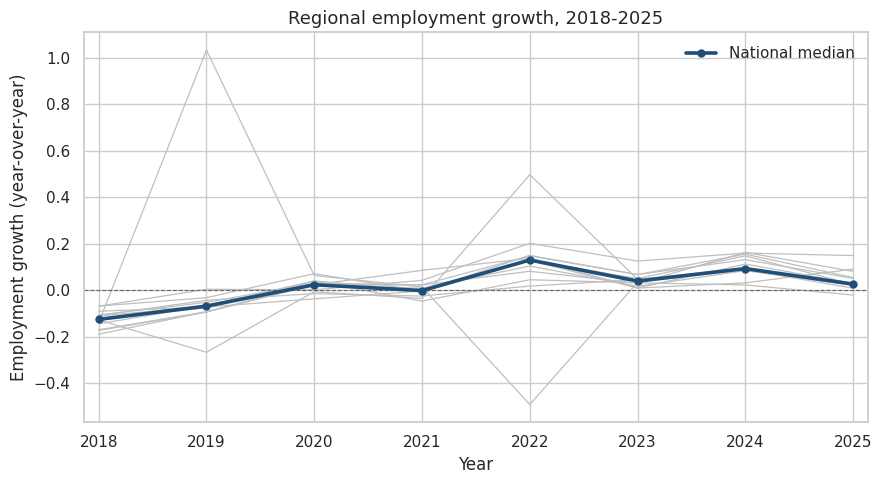

Year
2018   -0.1259
2019   -0.0687
2020    0.0230
2021   -0.0019
2022    0.1294
2023    0.0390
2024    0.0927
2025    0.0259


In [126]:
fig, ax = plt.subplots(figsize=(9, 5))

for prov, g in panel_fe.groupby("Province"):
    g = g.sort_values("Year")
    ax.plot(g["Year"], g["employment_growth"], color="0.75", linewidth=0.9, zorder=1)

national = panel_fe.groupby("Year")["employment_growth"].median()
ax.plot(national.index, national.values, color="#1f4e79", linewidth=2.6,
        marker="o", markersize=5, zorder=3, label="National median")

ax.axhline(0, color="0.4", linewidth=0.8, linestyle="--", zorder=2)
ax.set_xlabel("Year")
ax.set_ylabel("Employment growth (year-over-year)")
ax.set_title("Regional employment growth, 2018-2025")
ax.legend(frameon=False, loc="best")
ax.margins(x=0.02)
fig.tight_layout()
fig.savefig("FS53_employment_growth_trend.png", dpi=200)
plt.show()

print(national.round(4).to_string())

### Step 5 — Outcome

The panel holds 117 region-year rows across thirteen regions and nine years. Computing year-over-year employment growth removes the first year, leaving 104 usable observations and 23 raw features. Property data covers 2021 onward only, so 52 rows carry no index level and 65 no growth rate. Population beyond 2022 is extrapolated and enters only as a denominator.

The national median is negative in 2018 and 2019 and turns positive from 2020 onward, so the sharpest contraction in this indicator precedes the pandemic year rather than coinciding with it. The `covid_shock_2020` variable used in Step 9 is named for the calendar year, not for an assumed cause.

## Step 6: Feature Engineering

Six ratio features are derived so that regions of very different sizes can be compared, and ten columns are removed because each is an arithmetic function of a column that is retained. The resulting set is then screened for redundancy and for its bivariate association with the target, which provides an independent reference against which the later importance results can be read.

In [127]:
X_engineered = X.copy()

n = X_engineered["n_projects"].replace(0, np.nan)

X_engineered["budget_per_project"]   = X_engineered["total_budget_sar"] / n
X_engineered["projects_per_area"]    = X_engineered["n_projects"] / X_engineered["total_area_sqm"].replace(0, np.nan)
X_engineered["budget_per_capita"]    = X_engineered["total_budget_sar"] / X_engineered["Population"]
X_engineered["projects_per_million"] = X_engineered["n_projects"] / X_engineered["Population"] * 1e6
X_engineered["budget_coverage"]      = X_engineered["known_budget_count"] / n
X_engineered["area_coverage"]        = X_engineered["known_area_count"] / n

redundant_cols = [
    "is_population_extrapolated",
    "total_budget_sar_billion",
    "known_budget_count",
    "known_area_count",
    "at_risk_count",
    "pct_projects",
    "pct_budget",
    "Population",
    "announced_projects",
    "announced_budget",
]
X_engineered = X_engineered.drop(columns=redundant_cols)

Ten columns are dropped. Seven are arithmetic functions of a retained column: the billion-scaled budget, the two known-value counts now expressed as coverage ratios, the at-risk count now expressed as a rate, the two national share columns, and population, which enters only as a denominator. The remaining three are dropped for different reasons. Announced projects and announced budget are undated stock assigned identically to every year, so they hold no within-region variation and cannot inform a year-level prediction. The population extrapolation flag is dropped because population itself is no longer a feature.

In [128]:
print(f"features: {X_engineered.shape[1]} | rows: {X_engineered.shape[0]}")

corr = X_engineered.corr(numeric_only=True).abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_pairs = upper.stack()[lambda s: s > 0.95].round(3)

print("pairs with correlation > 0.95:",
      high_corr_pairs.to_dict() if len(high_corr_pairs) else "none -- clean")

features: 19 | rows: 104
pairs with correlation > 0.95: {('n_projects', 'active_projects'): 0.953, ('budget_per_project', 'budget_per_capita'): 0.953}


Two pairs correlate above 0.95. Neither is removed: gradient-boosted trees and the two neural architectures are unaffected by collinearity in the way a linear model would be, and dropping one member of each pair would discard information that the ablation in Step 7 is designed to isolate. The pairing is noted here because it explains why importance may be split arbitrarily between two near-identical features.

### Is the property data missing at random?

In [129]:
from scipy.stats import spearmanr

level_col = f"real_estate_vs_own_{base_year}"

diag = panel_fe[["Year"]].copy()
diag["growth_missing"] = X_engineered["real_estate_growth"].isna().astype(int)
diag["level_missing"] = X_engineered[level_col].isna().astype(int)
diag["year_ge_2022"] = (diag["Year"] >= 2022).astype(int)

print(pd.crosstab(diag["Year"], diag["growth_missing"]).to_string())
print()
for col in ["growth_missing", "level_missing"]:
    r, p = spearmanr(diag[col], diag["year_ge_2022"])
    print(f"{col} vs (Year >= 2022): rho = {r:+.3f} (p = {p:.3g})")

growth_missing   0   1
Year                  
2018             0  13
2019             0  13
2020             0  13
2021             0  13
2022            13   0
2023            13   0
2024            13   0
2025            13   0

growth_missing vs (Year >= 2022): rho = -1.000 (p = 0)
level_missing vs (Year >= 2022): rho = -0.775 (p = 5.13e-22)


Property growth is missing for every row before 2022 and present for every row after, a perfect deterministic relationship. The missingness is a property of the publication schedule, not of the regions. Any model that appears to use this feature is partly using a proxy for the year, which the ablation below separates.

In [130]:
new_feats = ["budget_per_project", "projects_per_area", "budget_per_capita",
             "projects_per_million", "budget_coverage", "area_coverage"]

n_inf = np.isinf(X_engineered[new_feats].to_numpy(dtype="float64")).sum()
print("broken values (inf):", int(n_inf))
print(X_engineered[new_feats].describe().to_string(float_format=lambda v: f"{v:,.4g}"))

broken values (inf): 0
       budget_per_project  projects_per_area  budget_per_capita  projects_per_million  budget_coverage  area_coverage
count                 104                104                104                   104              104            104
mean            2.012e+09          1.487e-06          4.946e+04                 22.45           0.6448         0.7386
std             2.395e+09          2.221e-06          5.539e+04                 9.741           0.1624         0.1863
min             1.108e+08           1.58e-08              1,074                 6.137           0.3333         0.4286
25%             2.964e+08          3.283e-07              5,645                 13.28           0.5385         0.5833
50%             6.346e+08          6.366e-07              8,743                 23.87           0.7143           0.75
75%             2.846e+09          1.478e-06          9.475e+04                 29.56             0.75         0.8966
max             8.472e+09        

In [131]:
from scipy.stats import pearsonr, spearmanr

y = panel_fe["employment_growth"]

corr_rows = []
for col in X_engineered.columns:
    sub = pd.DataFrame({"x": X_engineered[col], "y": y}).dropna()
    if sub["x"].nunique() < 3:
        continue
    r, p_r = pearsonr(sub["x"], sub["y"])
    rho, p_s = spearmanr(sub["x"], sub["y"])
    corr_rows.append({"feature": col,
                      "pearson_r": r,      "p_linear": p_r,
                      "spearman_rho": rho, "p_monotonic": p_s,
                      "gap": abs(rho) - abs(r)})

corr_tbl = (pd.DataFrame(corr_rows)
            .sort_values("spearman_rho", key=abs, ascending=False)
            .set_index("feature")
            .round(3))
corr_tbl.to_csv("S61_eda_feature_target_correlations.csv")

alpha = 0.05 / len(corr_tbl)
strong = corr_tbl[corr_tbl["p_monotonic"] < alpha]

print(f"n = {len(y)} observations | {len(corr_tbl)} features tested | Bonferroni alpha = {alpha:.4f}")
print(f"features passing the corrected threshold: {len(strong)} -> "
      f"{strong.index.tolist() if len(strong) else 'none'}\n")
print(corr_tbl.to_string())

n = 104 observations | 19 features tested | Bonferroni alpha = 0.0026
features passing the corrected threshold: 4 -> ['Year', 'new_projects_this_year', 'completed_this_year', 'budget_started_this_year']

                          pearson_r  p_linear  spearman_rho  p_monotonic     gap
feature                                                                         
Year                         0.3360    0.0000        0.6530       0.0000  0.3170
new_projects_this_year      -0.2080    0.0340       -0.5000       0.0000  0.2920
completed_this_year         -0.1820    0.0640       -0.3350       0.0010  0.1530
budget_started_this_year    -0.0970    0.3280       -0.3250       0.0010  0.2290
real_estate_vs_own_2023      0.0850    0.5020        0.2150       0.0860  0.1300
real_estate_growth           0.0700    0.6230        0.1820       0.1980  0.1120
active_budget               -0.0730    0.4640       -0.0860       0.3860  0.0130
budget_per_capita            0.0790    0.4280       -0.0740       0

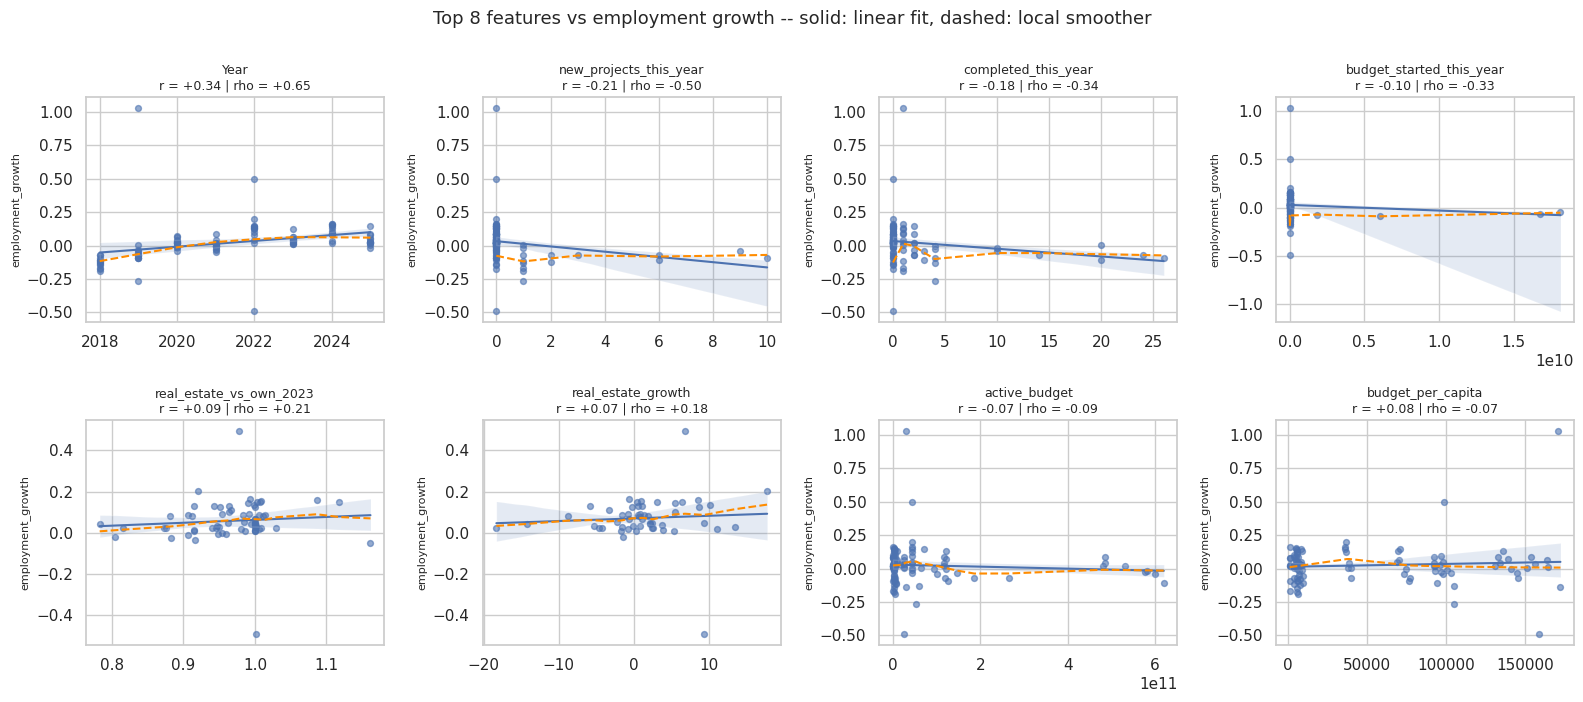

In [132]:
cols = corr_tbl.index[:8].tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.ravel()

for ax, col in zip(axes, cols):
    sub = pd.DataFrame({"x": X_engineered[col], "y": y}).dropna()
    sns.regplot(x="x", y="y", data=sub, ax=ax, ci=95,
                scatter_kws={"s": 18, "alpha": 0.6}, line_kws={"linewidth": 1.5})
    sns.regplot(x="x", y="y", data=sub, ax=ax, lowess=True, scatter=False,
                line_kws={"linewidth": 1.5, "linestyle": "--", "color": "darkorange"})
    ax.set_title(f"{col}\nr = {corr_tbl.loc[col,'pearson_r']:+.2f} | "
                 f"rho = {corr_tbl.loc[col,'spearman_rho']:+.2f}", fontsize=9)
    ax.set_xlabel(""); ax.set_ylabel("employment_growth", fontsize=8)

fig.suptitle("Top 8 features vs employment growth -- solid: linear fit, dashed: local smoother",
             fontsize=13, y=1.0)
plt.tight_layout()
plt.savefig("FS61_eda_feature_target_relationships.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 6 — Outcome

Nineteen features enter the modelling stage. Only four show a monotonic association with the target surviving a Bonferroni-corrected threshold, and the strongest of them is the year index rather than any project attribute. The three features closest to the research question - project count, total budget and sector concentration - show no association at all, and their plots form vertical columns because each is constant within a region while the target moves.

## Step 7: Model Comparison — Unified LOGO-CV Protocol

Three architectures and four naive baselines are evaluated under identical leave-one-region-out folds. The baselines matter more than the models here: with thirteen regions and a strong shared time effect, an error metric alone cannot show whether a model has learned anything region-specific. Performance is reported as a skill score against the strongest baseline, and differences are tested with a paired non-parametric test.

In [133]:
import torch
import tabm
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

groups = panel_fe["Province"].values

torch.set_num_threads(2)

In [134]:
X_engineered_f32 = X_engineered.astype("float32")

In [135]:
def train_tabm_fold(X_full, y_full, train_idx, test_idx, seed=42):
    torch.manual_seed(seed)

    train_mean = X_full.iloc[train_idx].mean()
    X_filled = X_full.fillna(train_mean).values

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_filled[train_idx])
    X_test  = scaler.transform(X_filled[test_idx])

    y_train = y_full[train_idx]
    y_mean, y_std = y_train.mean(), y_train.std() or 1.0

    model = tabm.TabM.make(
        n_num_features=X_train.shape[1],
        cat_cardinalities=None,
        d_out=1,
        n_blocks=2,
        d_block=128,
        k=16,
        dropout=0.1,
    )
    optimiser = torch.optim.AdamW(model.parameters(), lr=5e-3, weight_decay=1e-3)

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor((y_train - y_mean) / y_std, dtype=torch.float32)

    model.train()
    for _ in range(300):
        optimiser.zero_grad()
        pred = model(X_train_t, None).mean(1).squeeze(-1)
        loss = torch.nn.functional.mse_loss(pred, y_train_t)
        loss.backward()
        optimiser.step()

    model.eval()
    with torch.no_grad():
        X_test_t = torch.tensor(X_test, dtype=torch.float32)
        pred_scaled = model(X_test_t, None).mean(1).squeeze(-1).numpy()

    return pred_scaled * y_std + y_mean

This step requires a TabPFN access token from https://ux.priorlabs.ai/ to download the pre-trained model weights. The notebook will prompt for it when the cell runs, the token is not stored in the file.

In [136]:
import os
from getpass import getpass
from tabpfn import TabPFNRegressor

if "TABPFN_TOKEN" not in os.environ:
    os.environ["TABPFN_TOKEN"] = getpass("Enter your TabPFN access token: ")

print("Token Length:", len(os.environ["TABPFN_TOKEN"]))

Enter your TabPFN access token: ··········
Token Length: 53


In [137]:
logo = LeaveOneGroupOut()

groups_arr = panel_fe["Province"].values
years_arr  = panel_fe["Year"].values
y_arr      = y.values.astype(float)

In [138]:
def fold_metrics(name, region, y_true, y_pred):
    return {
        "model":  name,
        "region": region,
        "MAE":    mean_absolute_error(y_true, y_pred),
        "RMSE":   np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2":     r2_score(y_true, y_pred),
    }

In [139]:
def pooled_metrics(name, actuals, predictions, per_region_df):
    return {
        "model":           name,
        "MAE_pooled":      mean_absolute_error(actuals, predictions),
        "RMSE_pooled":     np.sqrt(mean_squared_error(actuals, predictions)),
        "R2_pooled":       r2_score(actuals, predictions),
        "MAE_mean_region": per_region_df["MAE"].mean(),
        "R2_mean_region":  per_region_df["R2"].mean(),
    }

In [140]:
def logo_evaluate(name, predict_fn):
    fold_rows = []
    predictions, actuals, regions, years = [], [], [], []

    for train_idx, test_idx in logo.split(X_engineered, y_arr, groups=groups_arr):
        pred = np.asarray(predict_fn(train_idx, test_idx), dtype=float).ravel()

        fold_rows.append(fold_metrics(name, groups_arr[test_idx][0], y_arr[test_idx], pred))

        predictions.extend(pred)
        actuals.extend(y_arr[test_idx])
        regions.extend(groups_arr[test_idx])
        years.extend(years_arr[test_idx])

    per_region_df = pd.DataFrame(fold_rows)
    out_of_fold_df = pd.DataFrame({
        "model": name, "region": regions, "Year": years,
        "actual": actuals, "predicted": predictions
    })

    pooled = pooled_metrics(name, actuals, predictions, per_region_df)
    return per_region_df, pooled, out_of_fold_df

In [141]:
def baseline_global_mean(train_idx, test_idx):
    return np.repeat(y_arr[train_idx].mean(), len(test_idx))

In [142]:
def baseline_year_mean(train_idx, test_idx):
    year_means = pd.Series(y_arr[train_idx]).groupby(years_arr[train_idx]).mean()
    return (pd.Series(years_arr[test_idx])
            .map(year_means)
            .fillna(y_arr[train_idx].mean())
            .values)

In [143]:
def baseline_year_median(train_idx, test_idx):
    year_medians = pd.Series(y_arr[train_idx]).groupby(years_arr[train_idx]).median()
    return (pd.Series(years_arr[test_idx])
            .map(year_medians)
            .fillna(np.median(y_arr[train_idx]))
            .values)

In [144]:
def baseline_persistence(train_idx, test_idx):
    order = np.argsort(years_arr[test_idx])
    values_in_time_order = y_arr[test_idx][order]
    lagged = np.concatenate(([y_arr[train_idx].mean()], values_in_time_order[:-1]))
    pred = np.empty(len(test_idx))
    pred[order] = lagged
    return pred

In [145]:
import xgboost as xgb

def m_xgb(train_idx, test_idx):
    model = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        random_state=42,
        missing=np.nan
    )
    model.fit(X_engineered.iloc[train_idx], y.iloc[train_idx])
    return model.predict(X_engineered.iloc[test_idx])

In [146]:
def m_tabm(train_idx, test_idx):
    return train_tabm_fold(X_engineered_f32, y_arr, train_idx, test_idx)

In [147]:
def m_tabpfn(train_idx, test_idx):
    model = TabPFNRegressor()
    model.fit(X_engineered.iloc[train_idx], y.iloc[train_idx])
    return model.predict(X_engineered.iloc[test_idx])

In [148]:
candidates = [
    ("Baseline: global mean",       baseline_global_mean),
    ("Baseline: year mean",         baseline_year_mean),
    ("Baseline: year median",       baseline_year_median),
    ("Baseline: persistence lag-1", baseline_persistence),
    ("XGBoost",                     m_xgb),
    ("TabM",                        m_tabm),
    ("TabPFN",                      m_tabpfn),
]

all_per, all_pooled, all_oof = [], [], []
for name, predict_fn in candidates:
    per, pooled, oof = logo_evaluate(name, predict_fn)
    all_per.append(per)
    all_pooled.append(pooled)
    all_oof.append(oof)

per_region_all = pd.concat(all_per, ignore_index=True)
oof_all        = pd.concat(all_oof, ignore_index=True)
benchmark      = pd.DataFrame(all_pooled).set_index("model")

baseline_rows = [m for m in benchmark.index if m.startswith("Baseline")]
best_base_mae = benchmark.loc[baseline_rows, "MAE_pooled"].min()
benchmark["skill_vs_best_baseline"] = 1 - benchmark["MAE_pooled"] / best_base_mae

tabpfn-v3-regressor-v3_default.ckpt: reconstructing file:   0%|          |  0.00B /  233MB            

tabpfn-v3-regressor-v3_default.ckpt: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/33.0 [00:00<?, ?B/s]

In [149]:
benchmark.to_csv("S71_model_benchmark_with_baselines.csv", encoding="utf-8-sig")
oof_all.to_csv("S72_out_of_fold_predictions.csv", index=False, encoding="utf-8-sig")
per_region_all.to_csv("S73_per_region_metrics.csv", index=False, encoding="utf-8-sig")

print(benchmark.round(4).to_string())

                             MAE_pooled  RMSE_pooled  R2_pooled  MAE_mean_region  R2_mean_region  skill_vs_best_baseline
model                                                                                                                   
Baseline: global mean            0.0835       0.1488    -0.0051           0.0835         -0.1092                 -0.6374
Baseline: year mean              0.0596       0.1436     0.0639           0.0596          0.4900                 -0.1680
Baseline: year median            0.0510       0.1366     0.1532           0.0510          0.6067                  0.0000
Baseline: persistence lag-1      0.1186       0.2023    -0.8565           0.1186         -0.4947                 -1.3244
XGBoost                          0.0697       0.1409     0.0990           0.0697          0.0796                 -0.3655
TabM                             0.0826       0.1423     0.0806           0.0826         -0.0612                 -0.6190
TabPFN                          

In [150]:
from scipy.stats import wilcoxon

baseline_names = [m for m in benchmark.index if m.startswith("Baseline")]
best_baseline = benchmark.loc[baseline_names, "MAE_pooled"].idxmin()

mae_by_region = per_region_all.pivot(index="region", columns="model", values="MAE")

test_rows = []
for model_name in ["XGBoost", "TabM", "TabPFN"]:
    diff = mae_by_region[model_name] - mae_by_region[best_baseline]
    _, p_value = wilcoxon(mae_by_region[model_name], mae_by_region[best_baseline])
    test_rows.append({
        "model": model_name,
        "dMAE (model - baseline)": diff.mean(),
        "regions where model wins": int((diff < 0).sum()),
        "out of": len(diff),
        "Wilcoxon p": p_value,
    })

baseline_test = pd.DataFrame(test_rows)

### Feature-group ablation

In [151]:
def xgb_on(feature_cols):
    X_subset = X_engineered[feature_cols]

    def predict_fn(train_idx, test_idx):
        model = xgb.XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05,
                                 random_state=42, missing=np.nan)
        model.fit(X_subset.iloc[train_idx], y.iloc[train_idx])
        return model.predict(X_subset.iloc[test_idx])

    return predict_fn


context_cols = [c for c in ["Year", "real_estate_growth", "real_estate_vs_own_2023"]
                if c in X_engineered.columns]
project_cols = [c for c in X_engineered.columns if c not in context_cols]
budget_cols = [c for c in X_engineered.columns if "budget" in c or c == "total_area_sqm"]

status_cols = [c for c in ["at_risk_rate", "active_projects", "active_budget"]
               if c in X_engineered.columns]

variants = {
    "Full model (all features)":      list(X_engineered.columns),
    "Without Year":                   [c for c in X_engineered.columns if c != "Year"],
    "Project features only":          project_cols,
    "Context only (Year + property)": context_cols,
    "Without property":               [c for c in X_engineered.columns if c not in ("real_estate_growth", level_col)],
    "Year only":                      ["Year"],
    "Count-based only (no budget)":   [c for c in X_engineered.columns if c not in budget_cols],
    "Budget-derived only":            budget_cols + ["Year"],
    "Without status-derived":         [c for c in X_engineered.columns if c not in status_cols],
}

ablation_rows = []
for label, cols in variants.items():
    _, pooled, _ = logo_evaluate(label, xgb_on(cols))
    ablation_rows.append({"variant": label, "n_features": len(cols),
                          "MAE_pooled": pooled["MAE_pooled"],
                          "R2_pooled": pooled["R2_pooled"],
                          "skill": 1 - pooled["MAE_pooled"] / best_base_mae})

ablation = pd.DataFrame(ablation_rows).set_index("variant")

In [152]:
ablation.to_csv("S74_feature_ablation.csv")

full_mae    = ablation.loc["Full model (all features)", "MAE_pooled"]
context_mae = ablation.loc["Context only (Year + property)", "MAE_pooled"]

print(f"MAE change from adding project features to context-only: {full_mae - context_mae:+.4f}\n")
print(ablation.round(4).to_string())

MAE change from adding project features to context-only: +0.0003

                                n_features  MAE_pooled  R2_pooled   skill
variant                                                                  
Full model (all features)               19      0.0697     0.0990 -0.3655
Without Year                            18      0.0783     0.0523 -0.5346
Project features only                   16      0.0846    -0.0443 -0.6574
Context only (Year + property)           3      0.0694    -0.0117 -0.3606
Without property                        17      0.0643     0.1150 -0.2596
Year only                                1      0.0596     0.0640 -0.1691
Count-based only (no budget)            12      0.1286    -1.6367 -1.5216
Budget-derived only                      8      0.0610     0.0939 -0.1949
Without status-derived                  16      0.0696     0.0848 -0.3635


A final variant addresses a leakage concern. Three features —
`at_risk_rate`, `active_projects` and `active_budget` — are derived from
project status as recorded at the extraction date, so applying that status
to earlier panel years gives the model information that was not available
in those years. Removing them changes pooled MAE by 0.0001 and skill from
−0.366 to −0.364, so the negative result for RQ1 does not depend on it.

One variant behaves anomalously: restricting the model to count-based features returns a pooled R² of −1.64, far worse than any other configuration. The two lists below show what each variant actually contains.

In [153]:
print("count-based:", variants["Count-based only (no budget)"])
print()
print("budget-derived:", variants["Budget-derived only"])

count-based: ['Year', 'n_projects', 'at_risk_rate', 'new_projects_this_year', 'active_projects', 'completed_this_year', 'sector_hhi', 'real_estate_growth', 'real_estate_vs_own_2023', 'projects_per_area', 'projects_per_million', 'area_coverage']

budget-derived: ['total_budget_sar', 'total_area_sqm', 'budget_started_this_year', 'active_budget', 'budget_per_project', 'budget_per_capita', 'budget_coverage', 'Year']


In [154]:
_, p, _ = logo_evaluate("check", xgb_on([c for c in variants["Count-based only (no budget)"] if c != "real_estate_growth"]))
print(f"count-based without real_estate_growth: MAE {p['MAE_pooled']:.4f} "
      f"(vs {ablation.loc['Count-based only (no budget)', 'MAE_pooled']:.4f} with it)")

count-based without real_estate_growth: MAE 0.1081 (vs 0.1286 with it)


Removing the property growth feature recovers part of the gap but not all of it, so the degradation is not attributable to a single feature. The pattern is consistent with an unstable fit on a set stripped of its only continuously varying inputs. It is reported rather than interpreted, since no configuration in this ablation achieved positive skill.

In [155]:
baseline_test.to_csv("S75_model_vs_baseline_wilcoxon.csv", index=False, encoding="utf-8-sig")

print("strongest baseline:", best_baseline, "\n")
print(baseline_test.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

strongest baseline: Baseline: year median 

  model  dMAE (model - baseline)  regions where model wins  out of  Wilcoxon p
XGBoost                   0.0186                         2      13      0.0012
   TabM                   0.0316                         0      13      0.0002
 TabPFN                   0.0024                         5      13      0.5417


In [156]:
plot_df = benchmark.sort_values("MAE_pooled")
colors = ["#C44E52" if name.startswith("Baseline") else "#4C72B0" for name in plot_df.index]

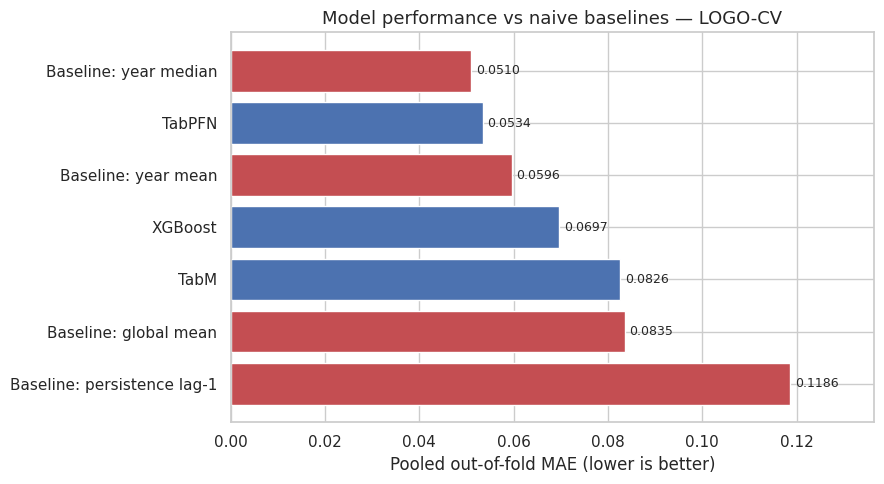

In [157]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df.index, plot_df["MAE_pooled"], color=colors)
ax.invert_yaxis()

ax.set_xlabel("Pooled out-of-fold MAE (lower is better)")
ax.set_title("Model performance vs naive baselines — LOGO-CV")

for i, value in enumerate(plot_df["MAE_pooled"]):
    ax.text(value + 0.001, i, f"{value:.4f}", va="center", fontsize=9)

ax.set_xlim(0, plot_df["MAE_pooled"].max() * 1.15)
plt.tight_layout()
plt.savefig("FS71_model_benchmark_mae.png", dpi=150, bbox_inches="tight")
plt.show()

### Seed stability

In [158]:
seeds = [42, 2, 200, 350, 80]
seed_rows = []

for seed in seeds:
    def tabm_with_seed(train_idx, test_idx, s=seed):
        return train_tabm_fold(X_engineered_f32, y_arr, train_idx, test_idx, seed=s)

    _, pooled, _ = logo_evaluate(f"TabM (seed {seed})", tabm_with_seed)
    seed_rows.append({"seed": seed,
                      "MAE_pooled":  pooled["MAE_pooled"],
                      "RMSE_pooled": pooled["RMSE_pooled"],
                      "R2_pooled":   pooled["R2_pooled"]})

tabm_seeds = pd.DataFrame(seed_rows)

In [159]:
tabm_seeds.to_csv("S76_tabm_seed_stability.csv", index=False, encoding="utf-8-sig")

spread = tabm_seeds["MAE_pooled"].max() - tabm_seeds["MAE_pooled"].min()
gap_to_base = tabm_seeds["MAE_pooled"].mean() - best_base_mae

print(f"MAE across seeds: {tabm_seeds['MAE_pooled'].mean():.4f} ± {tabm_seeds['MAE_pooled'].std():.4f}")
print(f"spread across seeds: {spread:.4f} | gap to strongest baseline: {gap_to_base:.4f}\n")
print(tabm_seeds.round(4).to_string(index=False))

MAE across seeds: 0.0830 ± 0.0010
spread across seeds: 0.0024 | gap to strongest baseline: 0.0320

 seed  MAE_pooled  RMSE_pooled  R2_pooled
   42      0.0826       0.1423     0.0806
    2      0.0816       0.1420     0.0852
  200      0.0840       0.1427     0.0766
  350      0.0840       0.1466     0.0252
   80      0.0827       0.1437     0.0625


### RQ1 — Answer

> **RQ1 — Can the features of Vision 2030 mega-projects be used to
> predict the economic growth of the region?**

**No. No model outperformed the year-median baseline.**

- Pooled MAE: year-median baseline 0.0510, TabPFN 0.0534, XGBoost 0.0697, TabM 0.0826
- Wilcoxon: XGBoost wins 2 of 13 regions, TabM 0, TabPFN 5 (p = 0.54)
- Ablation: **Year alone outperforms all nineteen engineered features**.

**Why.** The project register ends in 2020 while the panel runs to 2025.
Fifteen of eighteen features are frozen across five of the eight target
years, and those five contain zero new project starts. Regional growth in
this period is driven by a shared national year effect that project
portfolio features add nothing to.

### Feature importance — SHAP and permutation

The attributions below are computed on a model fitted to all 104 observations and explained on the same rows. They describe how the fitted model distributes its internal attributions, not what transfers to unseen regions. Out-of-fold permutation importance is computed afterwards as the generalisation reference, and the two are read together.

In [160]:
import shap

final_model = xgb.XGBRegressor(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    random_state=42, missing=np.nan
)
final_model.fit(X_engineered, y)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_engineered)

print("shape:", shap_values.shape)

shape: (104, 19)


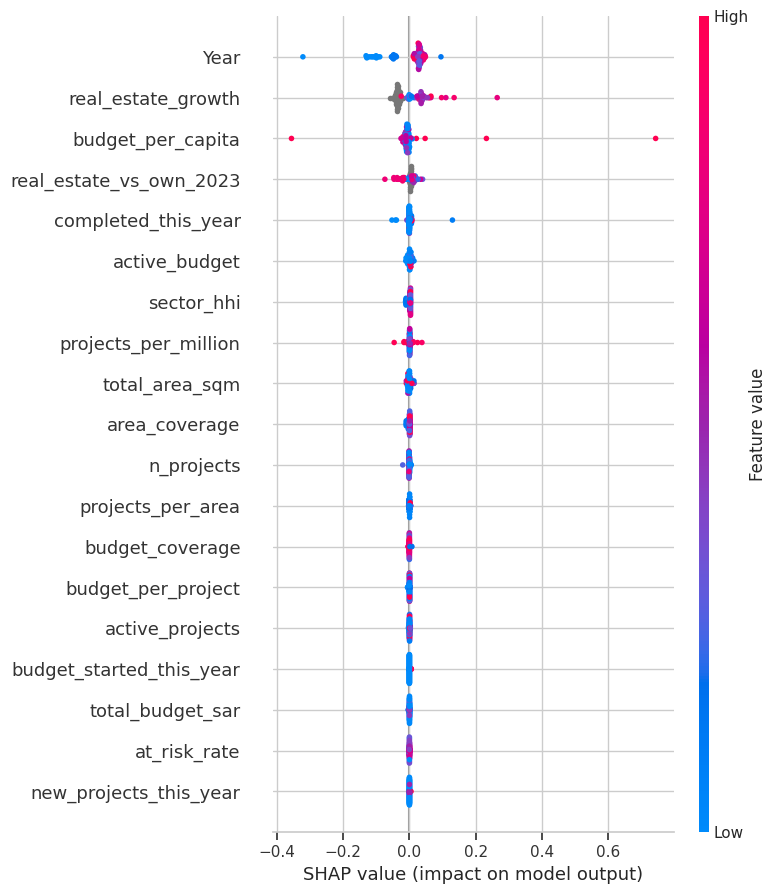

In [161]:
shap.summary_plot(shap_values, X_engineered, show=False)
plt.tight_layout()
plt.savefig("FS72_shap_summary_regression.png", dpi=200, bbox_inches="tight")
plt.show()

In [162]:
importances_reg = pd.Series(
    np.abs(shap_values).mean(axis=0), index=X_engineered.columns
).sort_values(ascending=False)

In [163]:
print("Importance as percentage of the total:")
print((importances_reg / importances_reg.sum() * 100).round(1).head(10))

Importance as percentage of the total:
Year                      31.7000
real_estate_growth        26.6000
budget_per_capita         14.8000
real_estate_vs_own_2023    9.4000
completed_this_year        3.1000
active_budget              2.8000
sector_hhi                 2.3000
projects_per_million       2.2000
total_area_sqm             2.1000
area_coverage              1.1000
dtype: float32


In [164]:
from sklearn.inspection import permutation_importance

shap_imp_reg = pd.Series(np.abs(shap_values).mean(axis=0), index=X_engineered.columns)
shap_pct_reg = shap_imp_reg / shap_imp_reg.sum() * 100

perm_scores = {col: [] for col in X_engineered.columns}

for train_idx, test_idx in logo.split(X_engineered, y, groups=groups):
    model = xgb.XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05,
                             random_state=42, missing=np.nan)
    model.fit(X_engineered.iloc[train_idx], y.iloc[train_idx])

    result = permutation_importance(model, X_engineered.iloc[test_idx], y.iloc[test_idx],
                                    n_repeats=10, random_state=42,
                                    scoring="neg_mean_absolute_error")

    for col, score in zip(X_engineered.columns, result.importances_mean):
        perm_scores[col].append(score)

perm_imp_reg = pd.Series({col: np.mean(scores) for col, scores in perm_scores.items()})

In [165]:
from scipy.stats import spearmanr

comparison_imp = pd.DataFrame({
    "SHAP_pct":    shap_pct_reg.round(2),
    "Permutation": perm_imp_reg.round(5),
}).sort_values("SHAP_pct", ascending=False)
comparison_imp.to_csv("S77_shap_vs_permutation_importance.csv", encoding="utf-8-sig")

rho, p_value = spearmanr(comparison_imp["SHAP_pct"], comparison_imp["Permutation"])

print(f"Spearman correlation between the two rankings: rho = {rho:+.3f} (p = {p_value:.3f})\n")
print(comparison_imp.head(12).to_string())

Spearman correlation between the two rankings: rho = +0.458 (p = 0.048)

                         SHAP_pct  Permutation
Year                      31.7000       0.0213
real_estate_growth        26.6500       0.0211
budget_per_capita         14.8000      -0.0001
real_estate_vs_own_2023    9.4100       0.0051
completed_this_year        3.0900       0.0001
active_budget              2.7800       0.0006
sector_hhi                 2.2700       0.0000
projects_per_million       2.1800      -0.0002
total_area_sqm             2.0500       0.0000
area_coverage              1.0900       0.0000
n_projects                 0.7800       0.0000
projects_per_area          0.6900       0.0000


### RQ2 — Answer

> **RQ2 — Which project attributes are most associated with regional
> development outcomes?**

**None that generalise.** SHAP attributes the largest share of importance
to Year (31.7%) and real_estate_growth (26.6%), but permutation importance
under the same LOGO-CV folds returns near-zero values for every feature,
including these two. The two measures answer different questions — SHAP
describes what the fitted model represents internally, permutation measures
what generalises to unseen regions — and since RQ1's model comparison
already established that no model beats the baseline, no feature-level
attribution can be trusted beyond describing an uninformative fit.

### Step 7 — Outcome

No model achieved positive skill against the year-median baseline. TabPFN matched it without exceeding it, XGBoost and TabM were significantly worse under a paired test. The ablation shows the year index alone outperforming all nineteen features, and TabM's seed spread is an order of magnitude smaller than its gap to the baseline, so the deficit is genuine rather than initialisation noise.

## Step 8: Regional Typology and Spatial Distribution

Three analyses complete the picture of regional distribution. The three largest investment hubs are compared against the remaining ten on size-independent measure, K-means clustering tests whether the regions fall into natural groups on those same measures, and the result is mapped. All three use variables normalised by population or project count, so that any grouping found reflects intensity rather than scale.

In [166]:
latest_year = panel["Year"].max()
panel_latest = panel[panel["Year"] == latest_year]

region_level = panel_latest.groupby("Province", as_index=False).agg(
    n_projects=("n_projects", "first"),
    total_budget_sar=("total_budget_sar", "first"),
    total_budget_sar_billion=("total_budget_sar_billion", "first"),
    at_risk_rate=("at_risk_rate", "first"),
    pct_projects=("pct_projects", "first"),
    pct_budget=("pct_budget", "first"),
    sector_hhi=("sector_hhi", "first"),
    population=("Population", "first"),
)

region_level["diversity_index"]      = 1 - region_level["sector_hhi"]
region_level["budget_per_capita"]    = region_level["total_budget_sar"] / region_level["population"]
region_level["projects_per_million"] = region_level["n_projects"] / region_level["population"] * 1e6

In [167]:
avg_cols = panel.groupby("Province", as_index=False).agg(
    avg_employment=("registered_employment", "mean"),
    avg_real_estate_growth=("real_estate_growth", "mean"),
)

region_level = region_level.merge(avg_cols, on="Province", how="left")

In [168]:
display_cols = [
    "Province",
    "diversity_index",
    "at_risk_rate",
    "budget_per_capita",
    "projects_per_million",
    "avg_real_estate_growth",
]

print("shape:", region_level.shape)
region_level[display_cols].round(3)

shape: (13, 14)


,Province,diversity_index,at_risk_rate,budget_per_capita,projects_per_million,avg_real_estate_growth
0,Al-Baha,0.7600,25.0000,"6,781",22.8800,-8.3310
1,Al-Jouf,0.6910,16.6700,"5,312",9.6760,0.1620
2,Al-Madinah Al-Monawarah,0.8510,27.4000,"96,405",33.2910,0.9250
3,Al-Qaseem,0.7920,48.2800,"5,738",21.1890,1.3500
4,Al-Riyadh,0.8170,34.2700,"36,128",24.1890,9.5120
5,Aseer,0.7750,30.7700,"3,547",6.1370,-0.9250
6,Eastern Region,0.8260,32.6400,"68,836",27.1490,0.5500
7,Hail,0.7700,25.0000,"5,001",35.6350,1.2810
8,Jazan,0.8000,19.4400,"131,380",24.7390,1.2190
9,Makkah Al-Mokarramah,0.8280,15.2700,"92,647",32.5880,3.5250


### Hub against peripheral regions

The inequality indices in Step 3 describe how uneven the distribution is but do not test whether the dominant regions differ systematically. The three regions holding the largest share of national investment are compared against the remaining ten on five size-independent measures. Hubs are defined in advance by budget share, not selected after inspecting outcomes.

In [169]:
from scipy.stats import mannwhitneyu
from math import comb

HUB_REGIONS = ["Al-Riyadh", "Makkah Al-Mokarramah", "Eastern Region"]

measures = [
    ("Budget per capita (SAR)", "budget_per_capita"),
    ("Projects per million", "projects_per_million"),
    ("At-risk rate (%)", "at_risk_rate"),
    ("Sector diversity index", "diversity_index"),
    ("Avg real estate growth", "avg_real_estate_growth"),
]

is_hub = region_level["Province"].isin(HUB_REGIONS)
alpha = 0.05 / len(measures)
min_p = 2 / comb(len(region_level), is_hub.sum())

test_rows = []
for label, col in measures:
    hub = region_level.loc[is_hub, col].dropna()
    peri = region_level.loc[~is_hub, col].dropna()
    u_stat, p_value = mannwhitneyu(hub, peri, alternative="two-sided")
    test_rows.append({
        "measure": label,
        "hub_median": round(hub.median(), 2),
        "periph_median": round(peri.median(), 2),
        "U": u_stat,
        "p_value": round(p_value, 3),
        "min_possible_p": round(min_p, 4),
        "verdict": "significant" if p_value < alpha else "underpowered",
    })

hub_tests = pd.DataFrame(test_rows)

In [170]:
hub_tests.to_csv("S81_hub_vs_peripheral_tests.csv", index=False, encoding="utf-8-sig")

print(f"{len(hub_tests)} tests | Bonferroni threshold: p < {alpha:.4f} | "
      f"smallest attainable p with 3 vs 10: {min_p:.4f}\n")
print(hub_tests.drop(columns=["min_possible_p", "verdict"]).to_string(index=False))

5 tests | Bonferroni threshold: p < 0.0100 | smallest attainable p with 3 vs 10: 0.0070

                measure  hub_median  periph_median       U  p_value
Budget per capita (SAR)      68,836          6,259 21.0000   0.3710
   Projects per million     27.1500        19.5300 23.0000   0.2170
       At-risk rate (%)     32.6400        26.2000 16.0000   0.9330
 Sector diversity index      0.8300         0.7600 27.0000   0.0490
 Avg real estate growth      3.5200         1.2500 22.0000   0.2870


No comparison reaches the corrected threshold, but this reflects the size of the groups rather than an absence of difference. Hub budget per capita is eleven times the peripheral median, yet with three regions against ten a single peripheral region ranking above a hub is enough to push the result past significance. These comparisons support the inequality measures descriptively, the measures themselves use all thirteen regions and do not depend on a binary grouping.

### K-means typology

The same five size-independent measures are used to test whether the regions fall into natural groups. The number of clusters is chosen by silhouette score across k = 2 to 5 rather than fixed in advance. Because the inputs are normalised by population and project count, any grouping that still tracks region size would indicate that normalisation has not removed the scale dimension - which is tested directly below. Region-level values are taken from the final panel year for the project-derived measures; because the register ends in 2020, these are effectively the 2020 stock carried forward against 2025 population. Average property growth is a mean across the years in which the index is published.

In [171]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_features = [
    "diversity_index",
    "at_risk_rate",
    "budget_per_capita",
    "projects_per_million",
    "avg_real_estate_growth",
]

X_cluster = region_level[cluster_features]
X_scaled = StandardScaler().fit_transform(X_cluster)

silhouette_by_k = {}
for k in [2, 3, 4, 5]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    silhouette_by_k[k] = silhouette_score(X_scaled, labels)

best_k = max(silhouette_by_k, key=silhouette_by_k.get)

In [172]:
print("missing values in the feature matrix:", int(X_cluster.isna().sum().sum()))
for k, score in silhouette_by_k.items():
    print(f"k={k}  silhouette = {score:.3f}")
print(f"selected k = {best_k}")

missing values in the feature matrix: 0
k=2  silhouette = 0.269
k=3  silhouette = 0.198
k=4  silhouette = 0.199
k=5  silhouette = 0.207
selected k = 2


In [173]:
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
region_level["cluster"] = kmeans_final.fit_predict(X_scaled)

cluster_profile = region_level.groupby("cluster")[cluster_features].mean()

scale_check = region_level.groupby("cluster")[[
    "n_projects",
    "total_budget_sar_billion",
    "avg_employment",
]].mean().round(1)

In [174]:
region_level.to_csv("S82_regional_typology_clusters.csv", index=False, encoding="utf-8-sig")

for c in sorted(region_level["cluster"].unique()):
    members = region_level.loc[region_level["cluster"] == c, "Province"].tolist()
    print(f"Cluster {c} (n={len(members)}): " + ", ".join(members))

print("\ncluster profiles:")
print(cluster_profile.round(3).to_string())

print("\nscale variables (not used in clustering):")
print(scale_check.to_string())

Cluster 0 (n=5): Al-Baha, Al-Jouf, Aseer, Najran, Tabouk
Cluster 1 (n=8): Al-Madinah Al-Monawarah, Al-Qaseem, Al-Riyadh, Eastern Region, Hail, Jazan, Makkah Al-Mokarramah, Northern Borders

cluster profiles:
         diversity_index  at_risk_rate  budget_per_capita  projects_per_million  avg_real_estate_growth
cluster                                                                                                
0                 0.7410       21.1540              4,981               12.2590                 -0.3800
1                 0.8030       30.6450             73,434               27.0800                  2.5470

scale variables (not used in clustering):
         n_projects  total_budget_sar_billion  avg_employment
cluster                                                      
0            9.0000                    4.3000         179,170
1           99.0000                  237.7000       1,305,744


### Choropleth map

Average regional employment is mapped to show the geographic pattern behind the concentration measures. This is visualisation rather than spatial analysis: no measure of spatial autocorrelation is computed, and the map is not used to support any inferential claim.

In [175]:
import folium
import json
from shapely.geometry import shape, mapping

In [176]:
!wget -q https://raw.githubusercontent.com/wjdanalharthi/GeoJSON-of-Saudi-Arabia-Regions/master/data/SA_regions.json -O sa_regions_raw.json

In [177]:
geo = json.load(open("sa_regions_raw.json"))
for f in geo["features"]:
    simplified = shape(f["geometry"]).simplify(0.01, preserve_topology=True)
    f["geometry"] = mapping(simplified)

In [178]:
geojson_to_province = {
    "Qassim": "Al-Qaseem", "Riyadh": "Al-Riyadh", "Tabuk": "Tabouk",
    "Madinah": "Al-Madinah Al-Monawarah", "Makkah": "Makkah Al-Mokarramah",
    "Northern Region": "Northern Borders", "Jawf": "Al-Jouf", "Hail": "Hail",
    "Bahah": "Al-Baha", "Jizan": "Jazan", "Asir": "Aseer", "Najran": "Najran",
    "Eastern Region": "Eastern Region",
}
for f in geo["features"]:
    f["properties"]["Province"] = geojson_to_province[f["properties"]["name"]]

In [179]:
employment_by_province = region_level.set_index("Province")["avg_employment"].to_dict()

for feature in geo["features"]:
    province = feature["properties"]["Province"]
    value = employment_by_province.get(province, 0)
    feature["properties"]["avg_employment_display"] = f"{value:,.0f}"

bins = list(region_level["avg_employment"].quantile([0, 0.25, 0.5, 0.75, 1]))

In [180]:
employment_map = folium.Map(location=[24, 45], zoom_start=5, tiles="cartodbpositron")

choropleth = folium.Choropleth(
    geo_data=geo,
    data=region_level,
    columns=["Province", "avg_employment"],
    key_on="feature.properties.Province",
    fill_color="YlOrRd",
    fill_opacity=0.85,
    line_opacity=0.4,
    line_color="black",
    legend_name="Average Regional Employment",
    bins=bins,
).add_to(employment_map)

folium.GeoJsonTooltip(
    fields=["Province", "avg_employment_display"],
    aliases=["Region:", "Average employment:"]
).add_to(choropleth.geojson)

title_html = ('<h3 align="center" style="font-size:16px"><b>'
              'Geographic distribution of average regional employment (2017-2025)'
              '</b></h3>')
employment_map.get_root().html.add_child(folium.Element(title_html))
employment_map.save("employment_choropleth.html")
employment_map

### Step 8 — Findings

No hub-versus-peripheral comparison survives correction, though the medians differ substantially, with three regions in one group the test cannot resolve differences of this size.

The two-cluster solution separates regions by scale, not by structure. A silhouette of 0.269 indicates weak grouping, and the clusters differ by an order of magnitude in project count and a factor of fifty in budget - despite using only size-normalised inputs. This is reported as a negative result: per-capita normalisation does not remove the size dimension, because investment accrues to large regions faster than their populations grow.

The same confound is examined formally in Step 9.

## Step 9: Regional Diversification and Resilience

Sector diversification is measured as 1 - HHI and related to four resilience measures derived from the employment growth path. Because the diversity index is computed from project counts, and regions differ in portfolio size by two orders of magnitude, any association found is then tested against portfolio size before it is interpreted.

In [181]:
panel_sorted = panel.sort_values(["Province", "Year"]).copy()
with_growth = panel_sorted.dropna(subset=["employment_growth"])

resilience = pd.DataFrame({
    "employment_volatility": with_growth.groupby("Province")["employment_growth"].std(),
    "volatility_ex2020":     with_growth[with_growth["Year"] != 2020].groupby("Province")["employment_growth"].std(),
    "covid_shock_2020":      panel_sorted[panel_sorted["Year"] == 2020].set_index("Province")["employment_growth"],
    "recovery_2021_2023":    with_growth[with_growth["Year"].between(2021, 2023)].groupby("Province")["employment_growth"].mean(),
    "sector_hhi":            panel_sorted.groupby("Province")["sector_hhi"].mean(),
    "n_projects":            panel_sorted.groupby("Province")["n_projects"].last(),
}).reset_index().rename(columns={"index": "Province"})

resilience["diversity_index"] = 1 - resilience["sector_hhi"]

assert len(resilience) == 13, f"expected 13 regions, found {len(resilience)}"
assert resilience["sector_hhi"].min() > 0, "a zero mean HHI invalidates the diversity index"

In [182]:
display_cols = [
    "Province", "sector_hhi", "diversity_index", "employment_volatility",
    "volatility_ex2020", "covid_shock_2020", "recovery_2021_2023", "n_projects"
]

n_sectors = int(df["sector_en"].nunique())
theoretical_max = 1 - 1 / n_sectors

print(f"diversity index range: {resilience['diversity_index'].min():.3f} to "
      f"{resilience['diversity_index'].max():.3f} "
      f"| theoretical maximum with {n_sectors} sectors: {theoretical_max:.3f}\n")

print(
    resilience[display_cols]
    .sort_values("diversity_index", ascending=False)
    .round(3)
    .to_string(index=False)
)

diversity index range: 0.691 to 0.851 | theoretical maximum with 10 sectors: 0.900

               Province  sector_hhi  diversity_index  employment_volatility  volatility_ex2020  covid_shock_2020  recovery_2021_2023  n_projects
Al-Madinah Al-Monawarah      0.1490           0.8510                 0.2210             0.2380           -0.0070              0.1690          73
   Makkah Al-Mokarramah      0.1710           0.8290                 0.0600             0.0640           -0.0150              0.0120         262
         Eastern Region      0.1740           0.8260                 0.0900             0.0930           -0.0380              0.0710         144
              Al-Riyadh      0.1830           0.8170                 0.0950             0.0970            0.0010              0.1230         213
                  Jazan      0.1990           0.8010                 0.0660             0.0690            0.0710              0.0550          36
              Al-Qaseem      0.2070           

In [183]:
resilience_measures = [
    ("Volatility, full period",    "employment_volatility"),
    ("Volatility, excluding 2020", "volatility_ex2020"),
    ("Covid shock 2020",           "covid_shock_2020"),
    ("Recovery 2021-2023",         "recovery_2021_2023"),
]

In [184]:
alpha = 0.05 / len(resilience_measures)

test_rows = []
for label, col in resilience_measures:
    sub = resilience[["diversity_index", col]].dropna()
    rho, p_value = spearmanr(sub["diversity_index"], sub[col])
    test_rows.append({
        "resilience measure": label,
        "rho": round(rho, 3),
        "p-value": round(p_value, 3),
        "verdict": "significant" if p_value < alpha else "not significant",
        "n": len(sub),
    })

diversity_results = pd.DataFrame(test_rows)

print(f"Bonferroni threshold for {len(resilience_measures)} tests: p < {alpha:.4f}\n")
print(diversity_results.to_string(index=False))
diversity_results.to_csv("S91_diversification_resilience_tests.csv", index=False, encoding="utf-8-sig")
resilience.to_csv("S92_regional_resilience_metrics.csv", index=False, encoding="utf-8-sig")

Bonferroni threshold for 4 tests: p < 0.0125

        resilience measure     rho  p-value         verdict  n
   Volatility, full period -0.0330   0.9150 not significant 13
Volatility, excluding 2020  0.0110   0.9720 not significant 13
          Covid shock 2020 -0.6980   0.0080     significant 13
        Recovery 2021-2023  0.4120   0.1620 not significant 13


One association survives the corrected threshold: more diversified regions contracted more sharply in 2020. Before this is interpreted, it must be established that the index is measuring what its name suggests.

### Verification: is the diversity index measuring diversification or size?

The diversity index is bounded by the number of projects a region records. Before interpreting any association, three checks are applied: partial correlation controlling for project count, a bias-corrected index compared against the concentration expected under random sampling, and the direct correlation between diversity and portfolio size.

In [185]:
H_inf = float((national_sector_share ** 2).sum())

conf = resilience.copy()
conf["hhi_expected"] = H_inf + (1 - H_inf) / conf["n_projects"]
conf["diversity_corrected"] = conf["hhi_expected"] - conf["sector_hhi"]


def partial_spearman(x, y, z):
    r = pd.DataFrame({"x": x, "y": y, "z": z}).dropna().rank()
    rx = r["x"] - np.polyval(np.polyfit(r["z"], r["x"], 1), r["z"])
    ry = r["y"] - np.polyval(np.polyfit(r["z"], r["y"], 1), r["z"])
    return spearmanr(rx, ry)


rows = []
for label, col in resilience_measures:
    sub = conf[["diversity_index", "diversity_corrected", "n_projects", col]].dropna()
    r_raw, p_raw = spearmanr(sub["diversity_index"], sub[col])
    r_par, p_par = partial_spearman(sub["diversity_index"], sub[col], sub["n_projects"])
    r_cor, p_cor = spearmanr(sub["diversity_corrected"], sub[col])
    rows.append({
        "resilience measure": label,
        "rho raw": round(r_raw, 3),
        "p raw": round(p_raw, 3),
        "rho size only": round(spearmanr(sub["n_projects"], sub[col])[0], 3),
        "rho partial": round(r_par, 3),
        "p partial": round(p_par, 3),
        "rho corrected": round(r_cor, 3),
        "p corrected": round(p_cor, 3),
    })

confound = pd.DataFrame(rows)
confound.to_csv("S93_diversity_size_confound.csv", index=False, encoding="utf-8-sig")

print(f"national sector concentration H = {H_inf:.3f}")
print(f"diversity vs portfolio size: rho = {spearmanr(conf['diversity_index'], conf['n_projects'])[0]:+.3f}")
print(f"observed HHI vs size-only expectation: rho = {spearmanr(conf['sector_hhi'], conf['hhi_expected'])[0]:+.3f}\n")
print(confound.to_string(index=False))

national sector concentration H = 0.173
diversity vs portfolio size: rho = +0.919
observed HHI vs size-only expectation: rho = +0.919

        resilience measure  rho raw  p raw  rho size only  rho partial  p partial  rho corrected  p corrected
   Volatility, full period  -0.0330 0.9150        -0.1570       0.0930     0.7620         0.1540       0.6160
Volatility, excluding 2020   0.0110 0.9720        -0.0880       0.1100     0.7210         0.1100       0.7210
          Covid shock 2020  -0.6980 0.0080        -0.6770      -0.4290     0.1440        -0.1040       0.7340
        Recovery 2021-2023   0.4120 0.1620         0.4760      -0.2470     0.4150        -0.4340       0.1380


In [186]:
region_en_map = {
    "Al-Riyadh": "Riyadh", "Makkah Al-Mokarramah": "Makkah",
    "Eastern Region": "Eastern", "Al-Madinah Al-Monawarah": "Madinah",
    "Al-Qaseem": "Qaseem", "Aseer": "Aseer", "Tabouk": "Tabouk",
    "Hail": "Hail", "Northern Borders": "N. Borders", "Jazan": "Jazan",
    "Najran": "Najran", "Al-Baha": "Baha", "Al-Jouf": "Jouf",
}

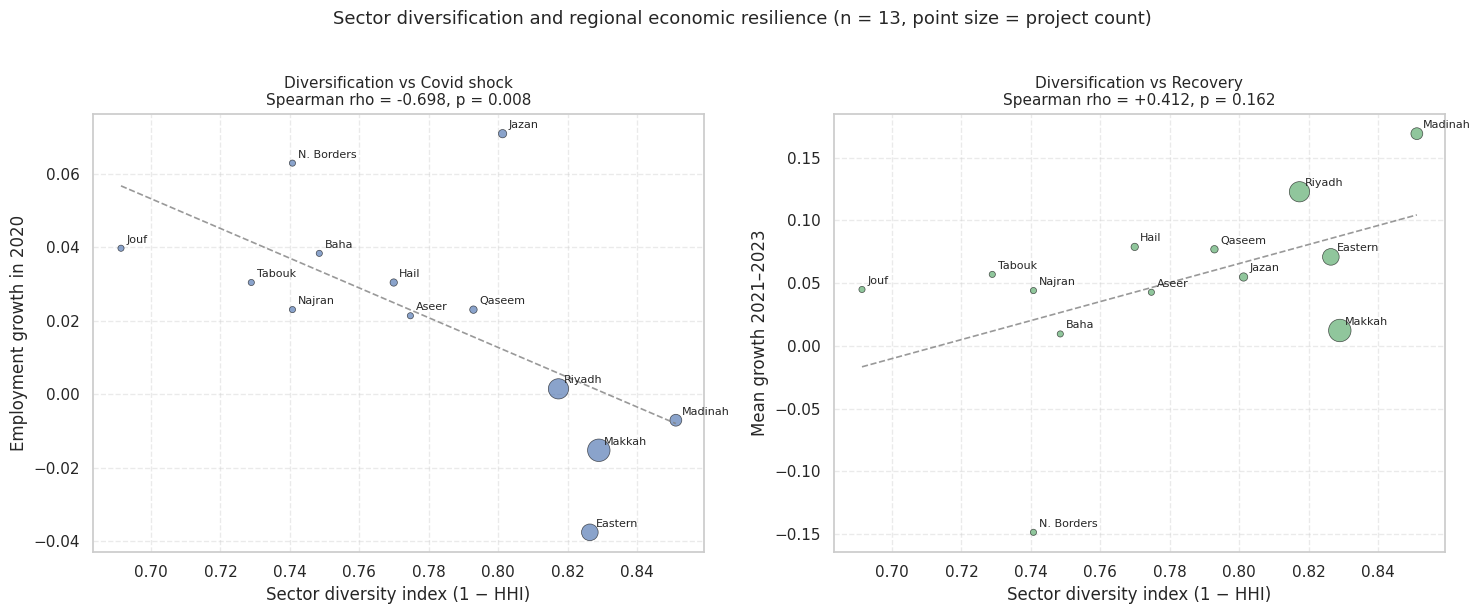

In [187]:
plot_data = resilience.copy()
plot_data["label"] = plot_data["Province"].map(region_en_map).fillna(plot_data["Province"])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

panels = [
    ("covid_shock_2020", "Employment growth in 2020",
     "Diversification vs Covid shock", "#4C72B0"),
    ("recovery_2021_2023", "Mean growth 2021–2023",
     "Diversification vs Recovery", "#55A868"),
]

for ax, (col, ylabel, title, colour) in zip(axes, panels):
    sub = plot_data.dropna(subset=[col])

    ax.scatter(sub["diversity_index"], sub[col],
               s=np.clip(sub["n_projects"], 20, 300), alpha=0.65,
               color=colour, edgecolors="black", linewidth=0.5)

    for _, region in sub.iterrows():
        ax.annotate(region["label"], (region["diversity_index"], region[col]),
                    fontsize=8, xytext=(4, 4), textcoords="offset points")

    slope_intercept = np.polyfit(sub["diversity_index"], sub[col], 1)
    x_line = np.linspace(sub["diversity_index"].min(), sub["diversity_index"].max(), 50)
    ax.plot(x_line, np.poly1d(slope_intercept)(x_line), "--",
            color="grey", linewidth=1.2, alpha=0.8)

    rho, p_value = spearmanr(sub["diversity_index"], sub[col])
    ax.set_title(f"{title}\nSpearman rho = {rho:+.3f}, p = {p_value:.3f}", fontsize=11)
    ax.set_xlabel("Sector diversity index (1 − HHI)")
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle="--", alpha=0.4)

fig.suptitle("Sector diversification and regional economic resilience (n = 13, point size = project count)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("FS91_diversification_resilience.png", dpi=200, bbox_inches="tight")
plt.show()

Point size encodes portfolio size. The largest regions cluster at the high-diversity end of both panels, which is the confound made visible: the apparent gradient in diversification is largely a gradient in scale.

### Sensitivity of the raw association

Two further checks are applied to the uncorrected measure. The first recomputes every test with the most volatile region removed, the second recomputes the concentration index over dated projects only rather than the full regional stock. Neither alters the conclusion above, since both operate on the index the confound analysis has already shown to be size-driven.

In [188]:
outlier_region = "Northern Borders"
reduced = resilience[resilience["Province"] != outlier_region]

test_rows = []
for label, col in resilience_measures:
    full_sample = resilience[["diversity_index", col]].dropna()
    rho_full, p_full = spearmanr(full_sample["diversity_index"], full_sample[col])

    reduced_sample = reduced[["diversity_index", col]].dropna()
    rho_reduced, p_reduced = spearmanr(reduced_sample["diversity_index"], reduced_sample[col])

    same_sign = np.sign(rho_full) == np.sign(rho_reduced)
    small_change = abs(rho_full - rho_reduced) < 0.25

    test_rows.append({
        "resilience measure": label,
        "rho (13)": round(rho_full, 3),    "p (13)": round(p_full, 3),
        "rho (12)": round(rho_reduced, 3), "p (12)": round(p_reduced, 3),
        "verdict": "stable" if (same_sign and small_change) else "sensitive",
    })

sensitivity = pd.DataFrame(test_rows)

In [189]:
sensitivity.to_csv("S94_outlier_sensitivity.csv", index=False, encoding="utf-8-sig")

print(f"Spearman tests excluding {outlier_region}\n")
print(sensitivity.to_string(index=False))

Spearman tests excluding Northern Borders

        resilience measure  rho (13)  p (13)  rho (12)  p (12)   verdict
   Volatility, full period   -0.0330  0.9150    0.0980  0.7620 sensitive
Volatility, excluding 2020    0.0110  0.9720    0.1540  0.6330    stable
          Covid shock 2020   -0.6980  0.0080   -0.7340  0.0070    stable
        Recovery 2021-2023    0.4120  0.1620    0.3640  0.2450    stable


In [190]:
def region_hhi_from(subset):
    shares = subset.groupby(["region", "sector_en"]).size()
    shares = shares / shares.groupby(level=0).transform("sum")
    return shares.groupby(level=0).apply(hhi)


ds_valid = d_sector_single[
    d_sector_single["region"].isin(official_regions)
    & ~d_sector_single.set_index(["name_project", "region"]).index.isin(multi_sector_projects)
]

hhi_variants = {
    "A: all projects": region_hhi_from(ds_valid),
    "B: dated only":   region_hhi_from(ds_valid[ds_valid["start_year"].notna()]),
}

ar_to_prov = {r: r for r in official_regions}

In [191]:
sensitivity_rows = []
for definition_label, hhi_series in hhi_variants.items():
    hhi_df = hhi_series.rename("hhi").reset_index()
    hhi_df["Province"] = hhi_df["region"].map(ar_to_prov)

    merged = (
        resilience.drop(columns=["sector_hhi", "diversity_index"], errors="ignore")
        .merge(hhi_df[["Province", "hhi"]], on="Province", how="left")
    )
    merged["diversity"] = 1 - merged["hhi"]

    for measure_label, col in resilience_measures:
        sub = merged[["diversity", col]].dropna()
        rho, p_value = spearmanr(sub["diversity"], sub[col])
        sensitivity_rows.append({
            "HHI definition":     definition_label,
            "resilience measure": measure_label,
            "rho": round(rho, 3),
            "p":   round(p_value, 3),
            "n":   len(sub),
        })

hhi_sensitivity = pd.DataFrame(sensitivity_rows)

In [192]:
hhi_sensitivity.to_csv("S95_hhi_definition_sensitivity.csv", index=False, encoding="utf-8-sig")

pivot_table = hhi_sensitivity.pivot(
    index="resilience measure", columns="HHI definition", values=["rho", "p"]
)
print(pivot_table.to_string())

                                       rho                             p              
HHI definition             A: all projects B: dated only A: all projects B: dated only
resilience measure                                                                    
Covid shock 2020                   -0.4120       -0.7250          0.1620        0.0050
Recovery 2021-2023                  0.3300        0.4340          0.2710        0.1380
Volatility, excluding 2020         -0.0110       -0.0110          0.9720        0.9720
Volatility, full period            -0.0440       -0.0550          0.8870        0.8590


In [193]:
recovery_long = with_growth[with_growth["Year"].between(2021, 2025)].groupby("Province")["employment_growth"].mean()

window_check = resilience[["Province", "diversity_index", "recovery_2021_2023"]].copy()
window_check["recovery_2021_2025"] = window_check["Province"].map(recovery_long)

rows = []
for label, col in [("Recovery 2021-2023", "recovery_2021_2023"),
                   ("Recovery 2021-2025", "recovery_2021_2025")]:
    sub = window_check[["diversity_index", col]].dropna()
    rho, p = spearmanr(sub["diversity_index"], sub[col])
    rows.append({"window": label, "rho": round(rho, 3), "p": round(p, 3), "n": len(sub)})

print(pd.DataFrame(rows).to_string(index=False))

            window    rho      p  n
Recovery 2021-2023 0.4120 0.1620 13
Recovery 2021-2025 0.3680 0.2160 13


The three-year recovery window is a judgement call, so the same test was
repeated over 2021–2025. The coefficient moves from +.412 to +.368 and
remains non-significant, so the conclusion does not depend on the window.

### RQ3 — Answer

> **RQ3 — Is there an association between sector diversification in a
> region's project portfolio and indicators of economic resilience?**

**Cannot be answered with this data — the diversity index measures
portfolio size, not diversification.**

The initial result looked significant: rho −0.70 (p 0.01) between
diversity and the 2020 employment shock. Verification showed it was
driven by region size.

| Test | rho | p |
|---|---|---|
| Diversity, raw | −0.70 | 0.01 |
| Project count alone | −0.68 | — |
| Diversity, controlling for count | −0.43 | 0.14 |
| Diversity, bias-corrected | −0.10 | 0.73 |

Project count alone (−0.68) explains almost the entire raw effect (−0.70).
Nothing survives correction.

**The cause.** A region with 6 projects cannot spread across 10 sectors,
while a region with 262 projects covers them automatically. HHI therefore rises as project
count falls, regardless of any real diversification. Diversity correlates
0.919 with project count in this data.

**This does not mean no relationship exists — only that this index cannot
detect one.**

## Step 10: Project Delay Classification

A supporting analysis at project level. Each project retains its own attributes here rather than being aggregated to a regional total, and the sample is fourteen times larger than the panel. The sample is restricted to projects that have entered delivery, since announced and proposed projects have no outcome to observe and cancellation is a distinct outcome from delay. Three architectures are compared against a baseline predicting each project's regional delay rate, and two sensitivity checks establish how much of the resulting performance reflects observation timing rather than project characteristics.

In [194]:
started_statuses = ["Completed", "Under construction", "Delayed", "Stalled"]
clf_df = projects_unique[projects_unique["status_en"].isin(started_statuses)].copy()
clf_df["region"] = clf_df["region"].where(~clf_df["is_multi_region"], "Multi-region")

clf_df["is_delayed"] = clf_df["status_en"].isin(["Delayed", "Stalled"]).astype(int)
clf_df["n_sector_tags"] = clf_df["all_sectors"].apply(len)

sector_cols = sorted(set(sector_en.values()))
for s in sector_cols:
    clf_df[f"sector_{s}"] = clf_df["all_sectors"].apply(lambda lst, s=s: int(s in lst))

feature_cols = ["region", "n_sector_tags", "budget_project",
                "area_sqm", "start_year"] + [f"sector_{s}" for s in sector_cols]

clf_features = clf_df[feature_cols].copy()
clf_features["region"] = clf_features["region"].astype("category")

y_clf = clf_df["is_delayed"]

excluded = projects_unique[~projects_unique["status_en"].isin(started_statuses)]
print(f"projects excluded as not started or cancelled: {len(excluded)}")
print(excluded["status_en"].value_counts().to_string())
print(f"\nanalysis sample: {clf_features.shape[0]} projects | {clf_features.shape[1]} features")
print(f"delayed or stalled: {int(y_clf.sum())} ({y_clf.mean():.1%})")
print(f"region levels: {clf_features['region'].nunique()} "
      f"(multi-region projects collapsed: {int(clf_df['is_multi_region'].sum())})")

clf_features.shape

projects excluded as not started or cancelled: 408
status_en
Announced    291
Proposed     110
Cancelled      7

analysis sample: 1121 projects | 17 features
delayed or stalled: 268 (23.9%)
region levels: 14 (multi-region projects collapsed: 8)


(1121, 17)

Eight multi-region projects are collapsed into a single Multi-region level rather than dropped, since at project level the region is a property of the project itself rather than an attribution problem. The delay rate is 23.9%, so the classifier is trained with class weighting throughout.

### Out-of-fold attributions

Unlike the regional panel, this sample is large enough to partition. A separate model is fitted on each training fold and used to explain only the held-out projects, so the attributions describe what generalises rather than what the model memorised.

In [195]:
from sklearn.model_selection import StratifiedKFold

scale_pos_weight_full = (y_clf == 0).sum() / (y_clf == 1).sum()

shap_values_clf = np.zeros(clf_features.shape)

for train_idx, test_idx in StratifiedKFold(5, shuffle=True, random_state=42).split(clf_features, y_clf):
    n_neg = (y_clf.iloc[train_idx] == 0).sum()
    n_pos = (y_clf.iloc[train_idx] == 1).sum()
    fold_model = xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        scale_pos_weight=n_neg / n_pos,
        eval_metric="logloss", random_state=42,
        enable_categorical=True, tree_method="hist"
    )
    fold_model.fit(clf_features.iloc[train_idx], y_clf.iloc[train_idx])
    shap_values_clf[test_idx] = shap.TreeExplainer(fold_model).shap_values(clf_features.iloc[test_idx])

print(f"positive class weight: {scale_pos_weight_full:.2f}")
print("SHAP values:", shap_values_clf.shape)

positive class weight: 3.18
SHAP values: (1121, 17)


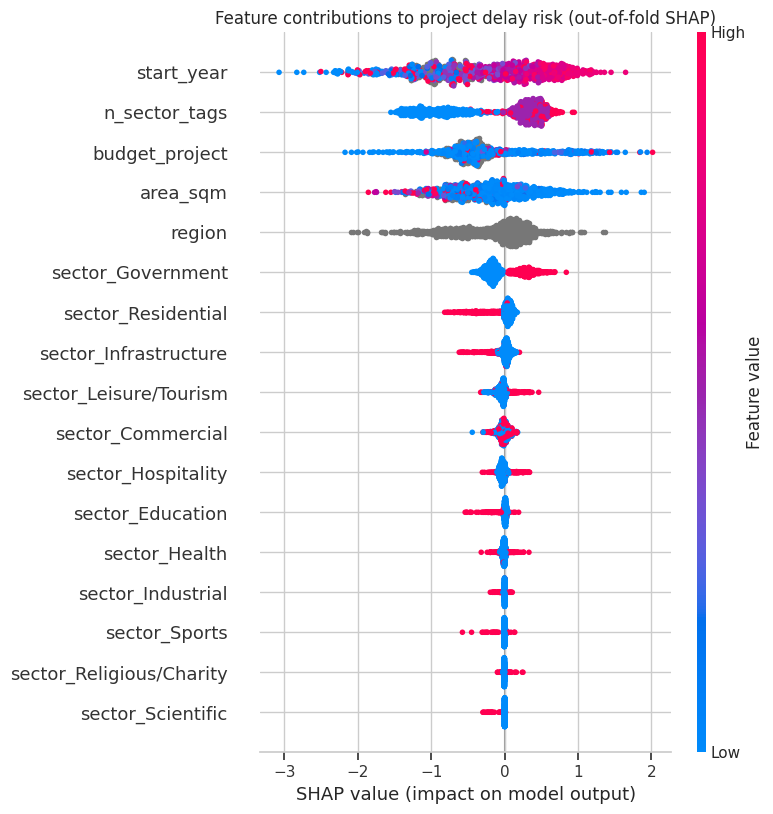

In [196]:
shap.summary_plot(shap_values_clf, clf_features, show=False)
plt.title("Feature contributions to project delay risk (out-of-fold SHAP)", fontsize=12)
plt.tight_layout()
plt.savefig("FS101_shap_summary_delay_classifier.png", dpi=150, bbox_inches="tight")
plt.show()

In [197]:
importances_clf = pd.Series(
    np.abs(shap_values_clf).mean(axis=0), index=clf_features.columns
).sort_values(ascending=False)

In [198]:
print("Mean absolute SHAP, as percentage of total:")
print((importances_clf / importances_clf.sum() * 100).round(1).to_string())

Mean absolute SHAP, as percentage of total:
start_year                 21.3000
n_sector_tags              17.7000
budget_project             16.3000
area_sqm                   14.0000
region                     11.8000
sector_Government           6.5000
sector_Residential          3.4000
sector_Infrastructure       1.9000
sector_Leisure/Tourism      1.8000
sector_Commercial           1.5000
sector_Hospitality          1.5000
sector_Education            0.8000
sector_Health               0.7000
sector_Industrial           0.3000
sector_Sports               0.2000
sector_Religious/Charity    0.2000
sector_Scientific           0.2000


SHAP ranks the sector indicators low individually, but that reflects how the signal is split across twelve binary columns. The raw delay rate by sector shows the pattern directly.

In [199]:
sector_risk = pd.DataFrame([
    {"sector": s,
     "n_projects": int(clf_df[f"sector_{s}"].sum()),
     "delay_rate_pct": round(clf_df.loc[clf_df[f"sector_{s}"] == 1, "is_delayed"].mean() * 100, 1)}
    for s in sector_cols
]).set_index("sector").sort_values("delay_rate_pct", ascending=False)

sector_risk.to_csv("S101_delay_rate_by_sector.csv", encoding="utf-8-sig")

print(f"overall delay rate: {clf_df['is_delayed'].mean():.1%} "
      f"| tags total {sector_risk['n_projects'].sum():,} across {len(clf_df):,} started projects\n")
print(sector_risk.to_string())

overall delay rate: 23.9% | tags total 2,067 across 1,121 started projects

                   n_projects  delay_rate_pct
sector                                       
Health                    111         36.0000
Government                371         34.2000
Infrastructure            206         30.6000
Hospitality               148         30.4000
Leisure/Tourism           199         29.6000
Religious/Charity          43         27.9000
Sports                     28         25.0000
Scientific                 29         24.1000
Education                 116         23.3000
Commercial                467         22.9000
Industrial                 96         22.9000
Residential               253         18.2000


Health, government and infrastructure projects carry the highest delay rates against an overall rate of 23.9%, residential and commercial the lowest. The three highest are typically publicly funded, consistent with longer approval cycles and greater exposure to budgetary revision. Tags sum to more than the sample size because sector membership is not exclusive.

In [200]:
from sklearn.metrics import (roc_auc_score, average_precision_score, confusion_matrix,
                             precision_score, recall_score, f1_score, classification_report)


def cv_evaluate_classifier(features_df, y, label, n_splits=5, seed=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    fold_rows = []
    oof_proba = np.zeros(len(y))
    oof_pred = np.zeros(len(y), dtype=int)

    for fold, (train_idx, test_idx) in enumerate(skf.split(features_df, y), start=1):
        n_neg = (y.iloc[train_idx] == 0).sum()
        n_pos = (y.iloc[train_idx] == 1).sum()

        model = xgb.XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9,
            scale_pos_weight=n_neg / n_pos,
            eval_metric="logloss", random_state=seed,
            enable_categorical=True, tree_method="hist"
        )
        model.fit(features_df.iloc[train_idx], y.iloc[train_idx])

        proba = model.predict_proba(features_df.iloc[test_idx])[:, 1]
        pred = model.predict(features_df.iloc[test_idx])
        oof_proba[test_idx] = proba
        oof_pred[test_idx] = pred

        fold_rows.append({
            "fold": fold,
            "ROC_AUC":   roc_auc_score(y.iloc[test_idx], proba),
            "PR_AUC":    average_precision_score(y.iloc[test_idx], proba),
            "precision": precision_score(y.iloc[test_idx], pred, zero_division=0),
            "recall":    recall_score(y.iloc[test_idx], pred, zero_division=0),
            "F1":        f1_score(y.iloc[test_idx], pred, zero_division=0),
        })

    folds = pd.DataFrame(fold_rows)

    print(f"{label}: pooled ROC-AUC {roc_auc_score(y, oof_proba):.3f} | "
          f"PR-AUC {average_precision_score(y, oof_proba):.3f} "
          f"(base rate {y.mean():.3f})")

    return folds, oof_proba, oof_pred

### Model comparison

A naive baseline predicting each project's regional delay rate establishes the floor. Any model must beat it to demonstrate that project attributes carry information beyond location.

In [201]:
def cv_evaluate_baseline(group_col, y, label, n_splits=5, seed=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof_proba = np.zeros(len(y))

    for train_idx, test_idx in skf.split(group_col, y):
        rates = y.iloc[train_idx].groupby(group_col.iloc[train_idx]).mean()
        oof_proba[test_idx] = (group_col.iloc[test_idx]
                               .map(rates)
                               .fillna(y.iloc[train_idx].mean())
                               .values)

    print(f"{label}: pooled ROC-AUC {roc_auc_score(y, oof_proba):.3f} | "
          f"PR-AUC {average_precision_score(y, oof_proba):.3f} "
          f"(base rate {y.mean():.3f})")
    return oof_proba

oof_proba_region = cv_evaluate_baseline(clf_df["region"].astype(str), y_clf,
                                        "Baseline: regional delay rate")

Baseline: regional delay rate: pooled ROC-AUC 0.559 | PR-AUC 0.276 (base rate 0.239)


In [202]:
folds_main, oof_proba_main, oof_pred_main = cv_evaluate_classifier(
    clf_features, y_clf, "Main model"
)
print(classification_report(y_clf, oof_pred_main,
                            target_names=["On schedule", "Delayed"], zero_division=0))

Main model: pooled ROC-AUC 0.749 | PR-AUC 0.486 (base rate 0.239)
              precision    recall  f1-score   support

 On schedule       0.85      0.78      0.81       853
     Delayed       0.44      0.57      0.50       268

    accuracy                           0.73      1121
   macro avg       0.65      0.67      0.66      1121
weighted avg       0.75      0.73      0.74      1121



At the default threshold the model identifies 152 of 268 delayed projects and raises 190 false alarms. Precision of 0.44 against a base rate of 0.239 means a flagged project is nearly twice as likely to be delayed as an unflagged one, but the model is a screening aid rather than a decision rule.

In [203]:
folds_main.to_csv("S102_classification_cv_folds.csv", index=False, encoding="utf-8-sig")
print(confusion_matrix(y_clf, oof_pred_main))

[[663 190]
 [116 152]]


In [204]:
leakage_variants = {
    "baseline (project attributes)":  clf_features,
    "without start_year":             clf_features.drop(columns=["start_year"]),
    "without start_year and budget":  clf_features.drop(columns=["start_year", "budget_project"]),
    "plus duration_days":             clf_features.assign(duration_days=clf_df["duration_days"].values),
}

summary_rows = []
for label, feats in leakage_variants.items():
    folds, _, _ = cv_evaluate_classifier(feats, y_clf, label)
    summary_rows.append({
        "variant": label,
        "n_features": feats.shape[1],
        "ROC_AUC": folds["ROC_AUC"].mean(),
        "±":       folds["ROC_AUC"].std(),
        "PR_AUC":  folds["PR_AUC"].mean(),
        "recall":  folds["recall"].mean(),
    })

leakage_summary = pd.DataFrame(summary_rows)

baseline (project attributes): pooled ROC-AUC 0.749 | PR-AUC 0.486 (base rate 0.239)
without start_year: pooled ROC-AUC 0.697 | PR-AUC 0.421 (base rate 0.239)
without start_year and budget: pooled ROC-AUC 0.656 | PR-AUC 0.362 (base rate 0.239)
plus duration_days: pooled ROC-AUC 0.845 | PR-AUC 0.638 (base rate 0.239)


In [205]:
leakage_summary.to_csv("S103_classification_leakage_check.csv", index=False, encoding="utf-8-sig")

base_auc = leakage_summary.set_index("variant").loc["baseline (project attributes)", "ROC_AUC"]
start_year_drop = base_auc - leakage_summary.set_index("variant").loc["without start_year", "ROC_AUC"]
duration_gain = leakage_summary.set_index("variant").loc["plus duration_days", "ROC_AUC"] - base_auc

print(f"ROC-AUC drop when start_year is removed: {-start_year_drop:+.3f}")
print(f"ROC-AUC gain when duration_days is added: {duration_gain:+.3f}\n")
print(leakage_summary.round(3).to_string(index=False))

ROC-AUC drop when start_year is removed: -0.054
ROC-AUC gain when duration_days is added: +0.093

                      variant  n_features  ROC_AUC      ±  PR_AUC  recall
baseline (project attributes)          17   0.7510 0.0510  0.4990  0.5670
           without start_year          16   0.6980 0.0350  0.4340  0.5000
without start_year and budget          15   0.6560 0.0290  0.3700  0.5110
           plus duration_days          18   0.8450 0.0350  0.6460  0.6600


Adding duration raises ROC-AUC by 0.093, the largest single gain in the table, and it is excluded for that reason: duration is observable only after a project has run its course, and delay is a property of that course. Removing start year costs 0.054, and removing budget as well costs a further 0.042 — so a considerable share of the model's discrimination reflects when a project was observed rather than what it is.

In [206]:
budget_variants = {
    "numeric budget_project":  clf_features,
    "without budget_project":  clf_features.drop(columns=["budget_project"]),
    "has_budget indicator only": (
        clf_features.drop(columns=["budget_project"])
        .assign(has_budget=clf_df["budget_project"].notna().astype(int).values)
    ),
}

budget_rows = []
for label, feats in budget_variants.items():
    folds, _, _ = cv_evaluate_classifier(feats, y_clf, label)
    budget_rows.append({
        "variant": label,
        "n_features": feats.shape[1],
        "ROC_AUC": folds["ROC_AUC"].mean(),
        "±":       folds["ROC_AUC"].std(),
    })

budget_summary = pd.DataFrame(budget_rows)
budget_summary.to_csv("S104_classification_budget_variants.csv", index=False, encoding="utf-8-sig")
print(budget_summary.round(3).to_string(index=False))

numeric budget_project: pooled ROC-AUC 0.749 | PR-AUC 0.486 (base rate 0.239)
without budget_project: pooled ROC-AUC 0.732 | PR-AUC 0.432 (base rate 0.239)
has_budget indicator only: pooled ROC-AUC 0.743 | PR-AUC 0.446 (base rate 0.239)
                  variant  n_features  ROC_AUC      ±
   numeric budget_project          17   0.7510 0.0510
   without budget_project          16   0.7320 0.0440
has_budget indicator only          17   0.7430 0.0450


Replacing the budget value with a binary indicator of whether a budget was recorded costs almost nothing (0.743 against 0.749), while removing budget entirely costs 0.017. The predictive contribution of budget therefore comes primarily from the disclosure pattern documented in Step 2, not from the monetary value.

In [207]:
clf_features_num = pd.get_dummies(clf_features, columns=["region"], drop_first=False).astype("float32")
y_clf_arr = y_clf.values.astype("float32")

def train_tabm_classifier_fold(X_full, y_full, train_idx, test_idx, seed=42):
    torch.manual_seed(seed)
    train_mean = X_full.iloc[train_idx].mean()
    X_filled = X_full.fillna(train_mean).values

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_filled[train_idx])
    X_test  = scaler.transform(X_filled[test_idx])
    y_train = y_full[train_idx]

    model = tabm.TabM.make(
        n_num_features=X_train.shape[1], cat_cardinalities=None,
        d_out=1, n_blocks=2, d_block=128, k=16, dropout=0.1,
    )
    optimiser = torch.optim.AdamW(model.parameters(), lr=5e-3, weight_decay=1e-3)

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)
    pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()])

    model.train()
    for _ in range(300):
        optimiser.zero_grad()
        logits = model(X_train_t, None).mean(1).squeeze(-1)
        loss = torch.nn.functional.binary_cross_entropy_with_logits(
            logits, y_train_t, pos_weight=pos_weight)
        loss.backward()
        optimiser.step()

    model.eval()
    with torch.no_grad():
        X_test_t = torch.tensor(X_test, dtype=torch.float32)
        proba = torch.sigmoid(model(X_test_t, None).mean(1).squeeze(-1)).numpy()
    return proba

skf = StratifiedKFold(5, shuffle=True, random_state=42)
oof_proba_tabm = np.zeros(len(y_clf_arr))

for train_idx, test_idx in skf.split(clf_features_num, y_clf_arr):
    oof_proba_tabm[test_idx] = train_tabm_classifier_fold(
        clf_features_num, y_clf_arr, train_idx, test_idx)

print(f"TabM Classifier: pooled ROC-AUC {roc_auc_score(y_clf_arr, oof_proba_tabm):.3f} | "
      f"PR-AUC {average_precision_score(y_clf_arr, oof_proba_tabm):.3f}")

TabM Classifier: pooled ROC-AUC 0.652 | PR-AUC 0.377


In [208]:
from tabpfn import TabPFNClassifier

oof_proba_tabpfn = np.zeros(len(y_clf))

for train_idx, test_idx in skf.split(clf_features_num, y_clf):
    model = TabPFNClassifier()
    model.fit(clf_features_num.iloc[train_idx], y_clf.iloc[train_idx])
    oof_proba_tabpfn[test_idx] = model.predict_proba(clf_features_num.iloc[test_idx])[:, 1]

print(f"TabPFN Classifier: pooled ROC-AUC {roc_auc_score(y_clf, oof_proba_tabpfn):.3f} | "
      f"PR-AUC {average_precision_score(y_clf, oof_proba_tabpfn):.3f}")

tabpfn-v3-classifier-v3_default.ckpt: reconstructing file:   0%|          |  0.00B /  213MB            

tabpfn-v3-classifier-v3_default.ckpt: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/33.0 [00:00<?, ?B/s]

TabPFN Classifier: pooled ROC-AUC 0.778 | PR-AUC 0.500


In [209]:
classifier_comparison = pd.DataFrame({
    "model": ["Baseline: regional delay rate", "XGBoost", "TabM", "TabPFN"],
    "ROC_AUC": [
        roc_auc_score(y_clf, oof_proba_region),
        roc_auc_score(y_clf, oof_proba_main),
        roc_auc_score(y_clf_arr, oof_proba_tabm),
        roc_auc_score(y_clf, oof_proba_tabpfn),
    ],
    "PR_AUC": [
        average_precision_score(y_clf, oof_proba_region),
        average_precision_score(y_clf, oof_proba_main),
        average_precision_score(y_clf_arr, oof_proba_tabm),
        average_precision_score(y_clf, oof_proba_tabpfn),
    ],
}).sort_values("ROC_AUC", ascending=False)

classifier_comparison.to_csv("S105_classifier_model_comparison.csv", index=False, encoding="utf-8-sig")
print(classifier_comparison.round(3).to_string(index=False))

                        model  ROC_AUC  PR_AUC
                       TabPFN   0.7780  0.5000
                      XGBoost   0.7490  0.4860
                         TabM   0.6520  0.3770
Baseline: regional delay rate   0.5590  0.2760


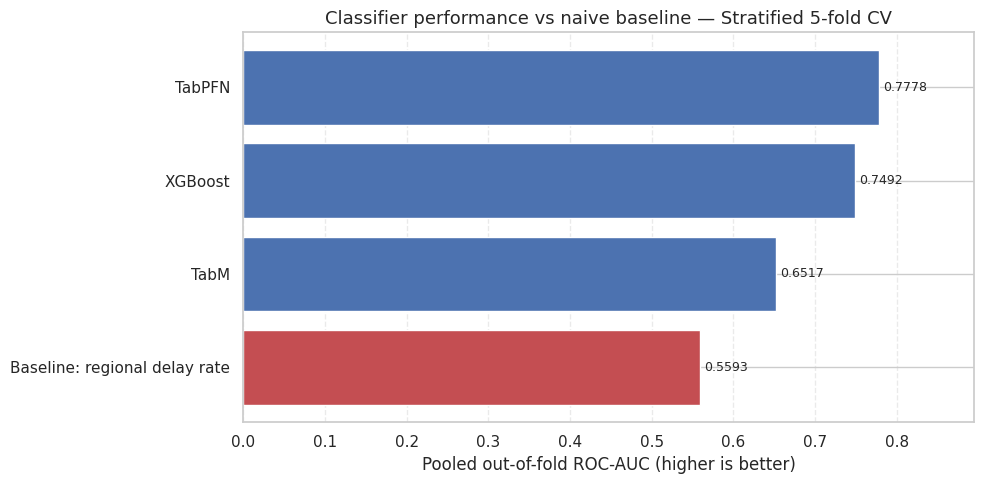

In [210]:
plot_data = classifier_comparison.sort_values("ROC_AUC", ascending=True).reset_index(drop=True)

colors = ["#4C72B0" if "Baseline" not in m else "#C44E52" for m in plot_data["model"]]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(plot_data["model"], plot_data["ROC_AUC"], color=colors)

for bar, value in zip(bars, plot_data["ROC_AUC"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{value:.4f}", va="center", fontsize=9)

ax.set_xlabel("Pooled out-of-fold ROC-AUC (higher is better)")
ax.set_title("Classifier performance vs naive baseline — Stratified 5-fold CV")
ax.set_xlim(0, plot_data["ROC_AUC"].max() * 1.15)
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("FS102_classifier_comparison_chart.png", dpi=150, bbox_inches="tight")
plt.show()

All three architectures beat the regional baseline, and TabPFN leads. XGBoost is retained as the reference model for interpretation because TreeSHAP is exact for tree ensembles, and the 0.03 gap does not justify losing exact attributions.

### Step 10 — Findings

**The classifier works, where the regional model did not.**

- TabPFN reaches 0.78 ROC-AUC, XGBoost 0.75, against 0.56 for the regional
  delay-rate baseline
- Ranked by out-of-fold SHAP: start year, sector count, budget, area, region
- Health, government and infrastructure carry the highest delay rates
- Leakage check: adding `duration_days` raised AUC by 0.094 — excluded
- Budget check: a has-budget indicator performs almost as well as the numeric
  value (0.743 vs 0.749), so the model partly captures disclosure behaviour
  rather than project economics

**What this establishes.** The same protocol applied to the same source at a
different unit of analysis produces a working model. The negative regional
result is therefore a property of the aggregated panel — 104 rows with
fifteen of eighteen features frozen — not of the method.

## Summary

| Question | Answer | Where |
|---|---|---|
| RQ1 — predicting regional growth | No. No model beat the year-median baseline | Step 7 |
| RQ2 — which attributes matter | None that generalise out of sample | Step 7 |
| RQ3 — diversification and resilience | Cannot be answered, the index measures portfolio size | Step 9 |
| RQ4 — spatial distribution | Highly concentrated: Gini 0.697 by budget, top three regions hold 77.7% | Step 3 |

Three of the four answers are negative, and each is supported rather than asserted: a feature-availability diagnostic, a naive-baseline comparison, and a size-confound correction respectively. The binding constraint throughout is the currency and completeness of the project register, not the capability of the models applied to it — a point the project-level classifier in Step 10 demonstrates directly by succeeding under the same protocol.